# XGBoost with Geodesic Loss for Cell Cycle Phase Prediction

This notebook implements XGBoost with custom geodesic loss function for circular cell cycle phase prediction.

**Key Features:**
- Custom geodesic objective function for XGBoost
- Custom geodesic evaluation metrics
- Leave-one-experiment-out cross-validation with weighted averaging
- Feature importance analysis

**Workflow:**
1. Setup and data loading
2. Define custom geodesic objective and metrics for XGBoost
3. Train full model
4. Cross-validation with experiment holdout (weighted evaluation)
5. Feature importance analysis


In [6]:
import sys
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
import xgboost as xgb

sys.path.insert(0, "/myhome/iris")

from src.data_pipeline.dataset import (
    ModularCellFeaturesDataset,
    create_transform_pipeline_from_config,
)
from src.data_pipeline.curve_projector import FucciCurveProjector
from src.evaluation.evaluator import Evaluator
from src.evaluation.metrics import MetricComputer

# Fix random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Imports loaded and random seeds fixed")

✓ Imports loaded and random seeds fixed


## 1. Setup and Configuration

In [ ]:
# Paths
h5_path = "/myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5"

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}
num_boost_round = 100
early_stopping_rounds = 10



## 2. Load and Prepare Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader

# Dataset configuration
data_config = {
    "data_source": {"h5_path": h5_path, "quality_filters": {}},
    "image_transforms": [],
    "data_split": [0.7, 0.2, 0.1],
    "fucci_1D_projection": True,
    "projection_shape": "polygon",
    "fucci_transform": "log",
    "feature_transforms": [{
        "class_path": "sklearn.preprocessing.StandardScaler",
        "init_args": {}
    }]
}

# Load dataset
print("Loading dataset...")
dataset = ModularCellFeaturesDataset(data_config=data_config, use_cache=True, include_exp_id=True)


# Split into train/val/test
train_df, val_df, test_df = dataset.split_set()

all_feature_cols = [col for col in train_df.columns if col not in dataset.label_names and col != "exp_id"]
train_df.drop(columns=["exp_id"], inplace=True)
val_df.drop(columns=["exp_id"], inplace=True)
test_df.drop(columns=["exp_id"], inplace=True)

df = dataset.get_dataset_df()
# df = polynomial_tansform(df, degree=2, columns=all_feature_cols)
exp_id_cv_splits = []
exp_ids = df["exp_id"].unique()
for exp_id in exp_ids:
    test_idx = df[df["exp_id"] == exp_id].index.to_numpy()
    hold_out_df = df[df["exp_id"] != exp_id]
    hold_out_idx = hold_out_df.index.to_numpy()
    # Randomly permute the hold-out indices
    np.random.shuffle(hold_out_idx)

    # Split into train and validation
    split_point = int(0.8 * len(hold_out_idx))
    train_idx = hold_out_idx[:split_point]
    val_idx = hold_out_idx[split_point:]

    exp_id_cv_splits.append({
        'exp_id': exp_id,
        'train_df': df.loc[train_idx].drop(columns=["exp_id"]),
        'val_df': df.loc[val_idx].drop(columns=["exp_id"]),
        'test_df': df.loc[test_idx].drop(columns=["exp_id"])
    })
print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")


Loading dataset...

Creating feature transform pipeline
   - Using [{'class_path': 'sklearn.preprocessing.StandardScaler', 'init_args': {}}] transforms

Creating image transform pipeline
   - Using [] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_23c07912.json

FILTERING STATISTICS
Total cells:                22,677
Valid cells:                16,759
Invalid cells:              5,918

Rejection reasons:
  - nuclei_too_large              : 2,540
  - exp_id_excluded               : 1,223
  - multiple_cells                : 966
  - failed_segmentation_nuclei_segmentation: 916
  - invalid_plane_count           : 177
  - failed_segmentation_segm

## 3. Custom Geodesic Objective and Metrics for XGBoost

In [9]:
def geodesic_objective(preds, dtrain):
    """
    Custom XGBoost objective function using geodesic distance.
    
    Args:
        preds: Predicted values (continuous)
        dtrain: Training data (DMatrix)
    
    Returns:
        grad: First derivative of loss w.r.t predictions
        hess: Second derivative of loss w.r.t predictions
    """
    # Get true labels
    labels = dtrain.get_label()
    
    # Wrap predictions to [0, 1]
    preds_wrapped = preds % 1.0
    
    # Compute residuals with circular wrap-around
    residuals = labels - preds_wrapped
    
    # Geodesic distance: use shortest path on circle
    sign = np.sign(residuals)
    abs_residuals = np.abs(residuals)
    
    # Shortest path
    use_wraparound = abs_residuals > 0.5
    geodesic_residuals = np.where(
        use_wraparound,
        -sign * (1.0 - abs_residuals),  # Go other direction
        residuals                       # Direct path
    )
    
    # Gradient: d/d(pred) of 0.5 * geodesic_distance^2 = -geodesic_residual
    grad = -geodesic_residuals
    
    # Hessian: second derivative (constant for squared loss)
    hess = np.ones_like(preds)
    
    return grad, hess


def geodesic_metric(preds, dtrain):
    """
    Custom evaluation metric: geodesic MAE.
    
    Args:
        preds: Predicted values
        dtrain: Data (DMatrix)
    
    Returns:
        name: Metric name
        value: Metric value (lower is better)
    """
    labels = dtrain.get_label()
    
    # Wrap predictions
    preds_wrapped = preds % 1.0
    
    # Compute geodesic distance
    residuals = labels - preds_wrapped
    abs_residuals = np.abs(residuals)
    geodesic_distances = np.minimum(abs_residuals, 1.0 - abs_residuals)
    
    # Mean absolute geodesic error
    mae = np.mean(geodesic_distances)
    
    return 'geodesic_mae', mae


def geodesic_rmse_metric(preds, dtrain):
    """Custom evaluation metric: geodesic RMSE."""
    labels = dtrain.get_label()
    preds_wrapped = preds % 1.0
    
    residuals = labels - preds_wrapped
    abs_residuals = np.abs(residuals)
    geodesic_distances = np.minimum(abs_residuals, 1.0 - abs_residuals)
    
    rmse = np.sqrt(np.mean(geodesic_distances ** 2))
    return 'geodesic_rmse', rmse

print("✓ Custom geodesic objective and metrics defined")

✓ Custom geodesic objective and metrics defined


## 4. Train XGBoost on Full Dataset

TRAINING XGBOOST WITH GEODESIC LOSS

Training XGBoost with 27 features...


[0]	train-rmse:0.22662	train-geodesic_mae:0.19972	val-rmse:0.22974	val-geodesic_mae:0.20227
[10]	train-rmse:0.17130	train-geodesic_mae:0.13980	val-rmse:0.18236	val-geodesic_mae:0.14577
[20]	train-rmse:0.15947	train-geodesic_mae:0.12177	val-rmse:0.17584	val-geodesic_mae:0.13094
[30]	train-rmse:0.15558	train-geodesic_mae:0.11451	val-rmse:0.17569	val-geodesic_mae:0.12723
[40]	train-rmse:0.15275	train-geodesic_mae:0.11038	val-rmse:0.17606	val-geodesic_mae:0.12591
[50]	train-rmse:0.15021	train-geodesic_mae:0.10737	val-rmse:0.17621	val-geodesic_mae:0.12555
[60]	train-rmse:0.14760	train-geodesic_mae:0.10443	val-rmse:0.17656	val-geodesic_mae:0.12545
[70]	train-rmse:0.14500	train-geodesic_mae:0.10162	val-rmse:0.17699	val-geodesic_mae:0.12521
[80]	train-rmse:0.14275	train-geodesic_mae:0.09914	val-rmse:0.17713	val-geodesic_mae:0.12491
[90]	train-rmse:0.14049	train-geodesic_mae:0.09664	val-rmse:0.17737	val-geodesic_mae:0.12487
[99]	train-rmse:0.13887	train-geodesic_mae:0.09466	val-rmse:0.17772	val

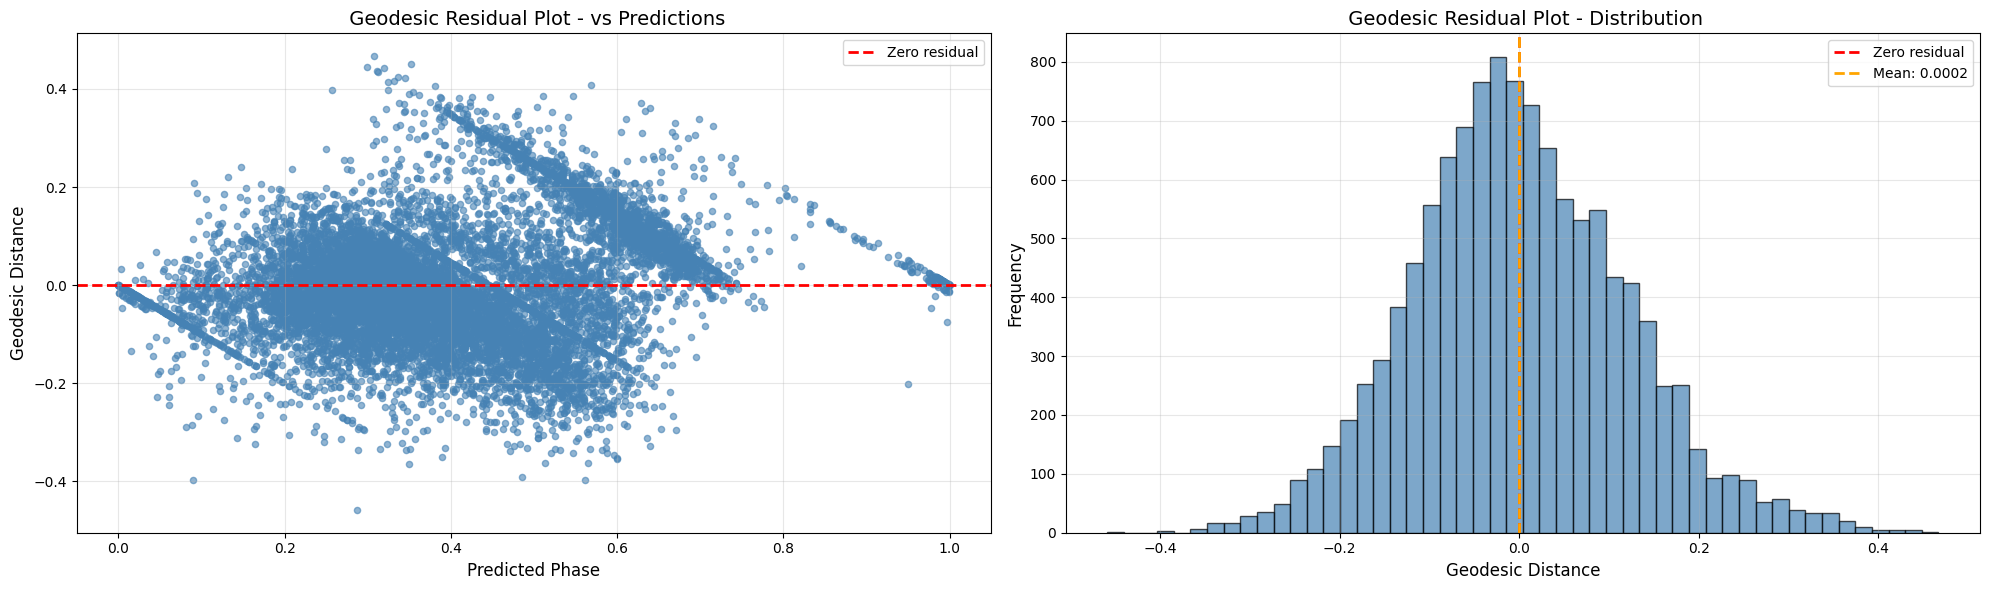

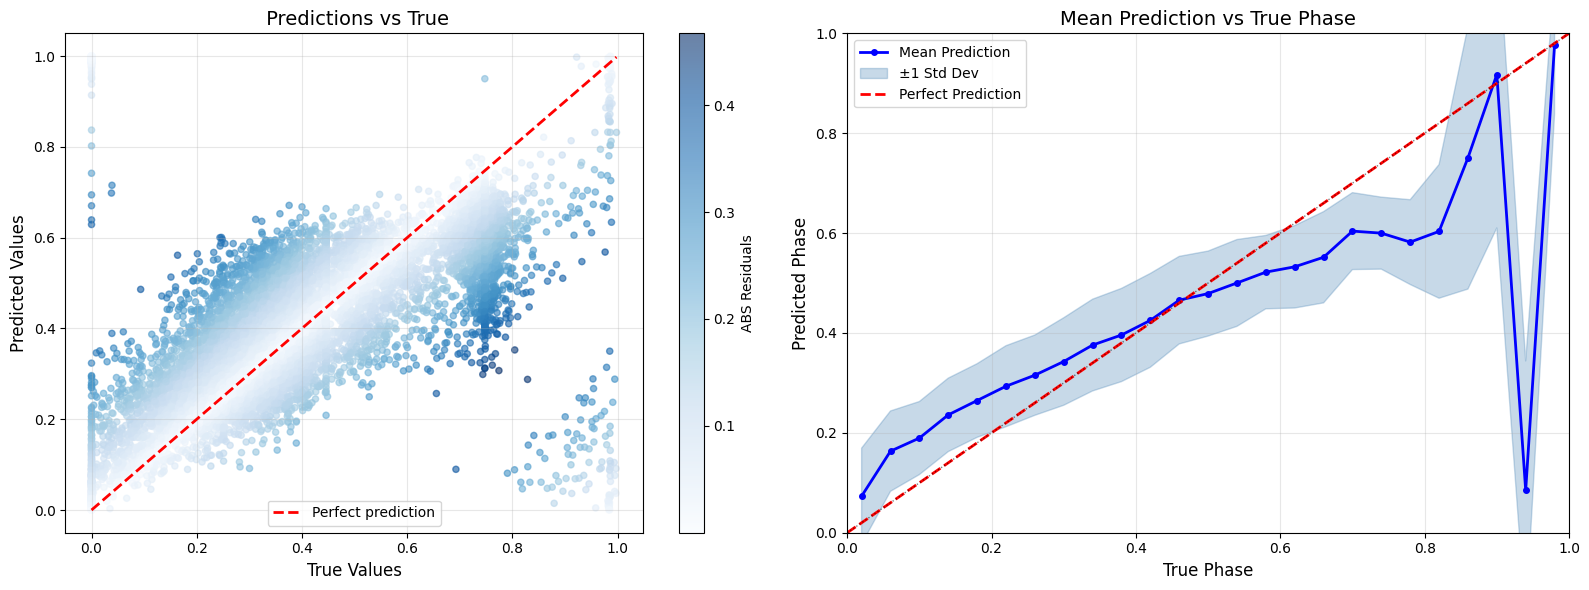

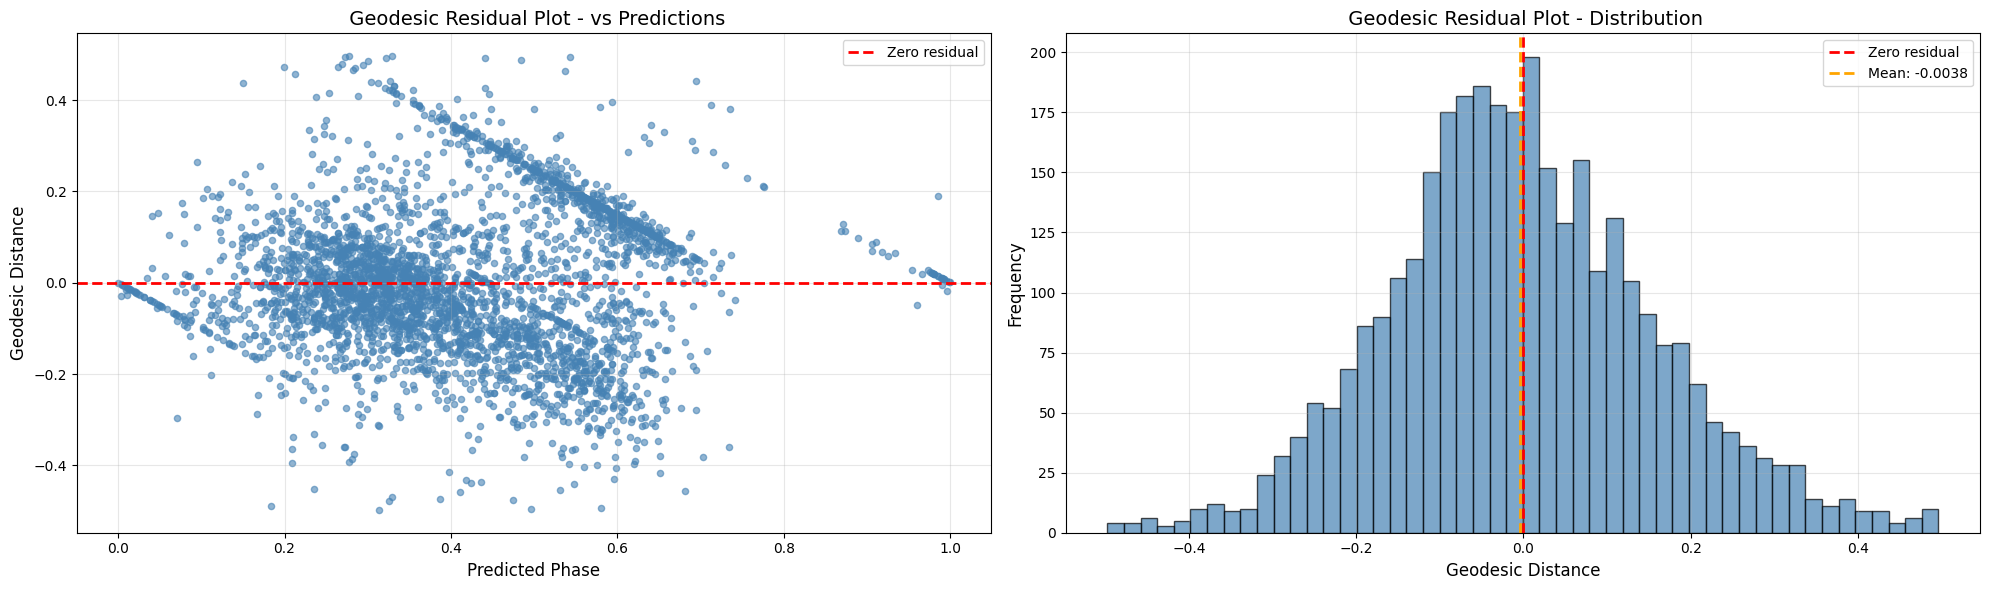

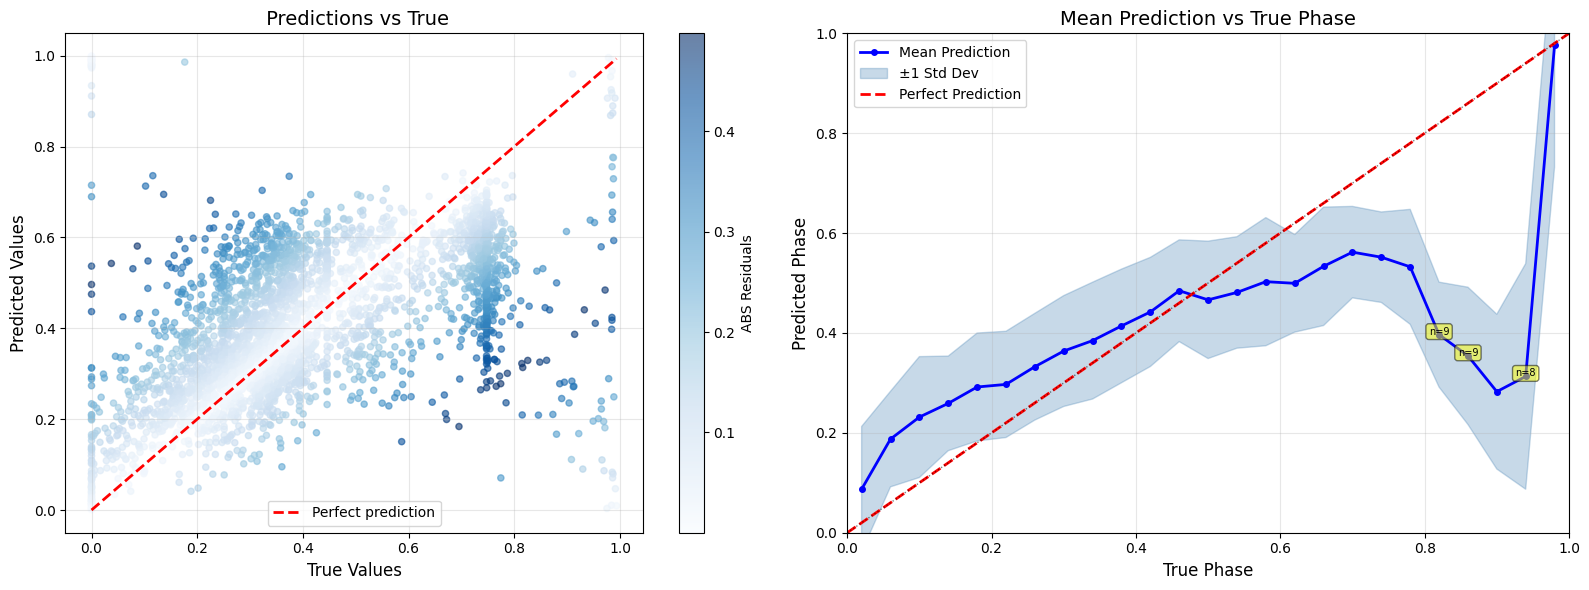

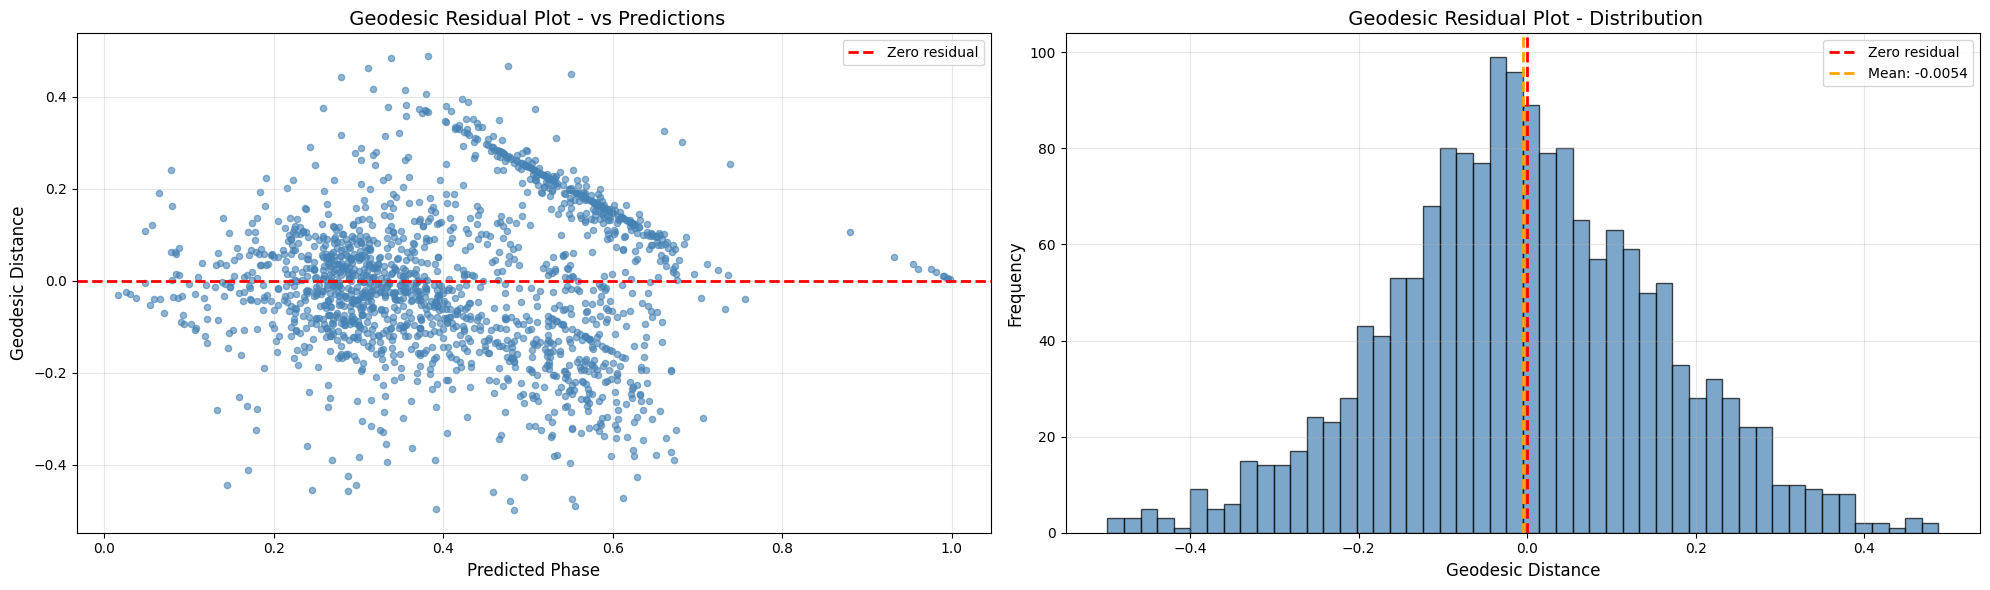

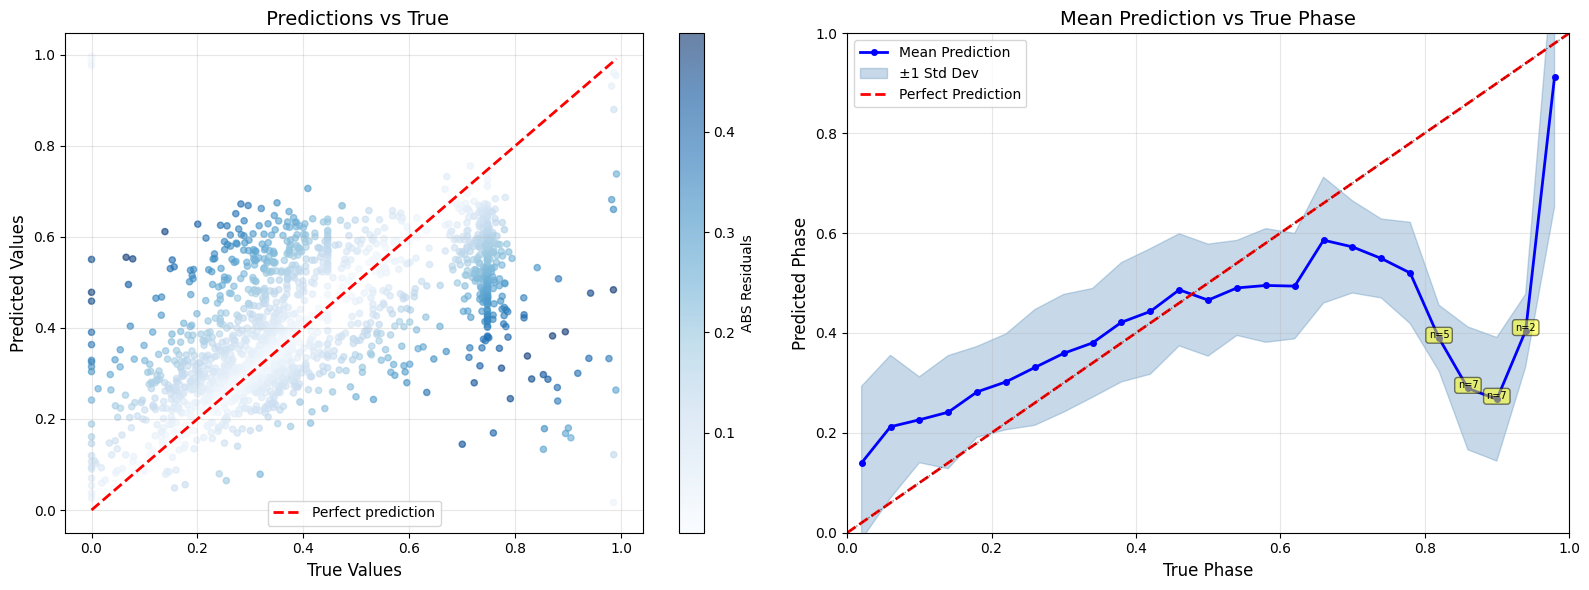


XGBoost Model Results:
  Train - MAE: 0.0947, MSE: 0.0145, RMSE: 0.1203, R²: 0.7034
  Val   - MAE: 0.1249, MSE: 0.0254, RMSE: 0.1593, R²: 0.4864
  Test  - MAE: 0.1267, MSE: 0.0260, RMSE: 0.1612, R²: 0.4585


In [ ]:
"""
Train XGBoost with custom geodesic objective on full dataset.
"""

print("=" * 80)
print("TRAINING XGBOOST WITH GEODESIC LOSS")
print("=" * 80)

# Update feature columns to include polynomial features
all_feature_cols = [col for col in train_df.columns if col not in dataset.label_names]

# Prepare data
X_train = train_df[all_feature_cols].values
y_train = train_df[dataset.label_names].values.ravel()
X_val = val_df[all_feature_cols].values
y_val = val_df[dataset.label_names].values.ravel()
X_test = test_df[all_feature_cols].values
y_test = test_df[dataset.label_names].values.ravel()

# Create DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=all_feature_cols)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=all_feature_cols)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=all_feature_cols)

# Training with custom objective
print(f"\nTraining XGBoost with {len(all_feature_cols)} features...")

evals = [(dtrain, 'train'), (dval, 'val')]
evals_result = {}

model_full_xgb = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    obj=geodesic_objective,              # Custom objective
    custom_metric=geodesic_metric,       # Custom metric
    evals_result=evals_result,
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=10
)

print(f"\n✓ Training complete. Best iteration: {model_full_xgb.best_iteration}")

# Predictions
pred_xgb_train = model_full_xgb.predict(dtrain) % 1.0
pred_xgb_val = model_full_xgb.predict(dval) % 1.0
pred_xgb_test = model_full_xgb.predict(dtest) % 1.0

# Evaluate
evaluator = Evaluator(projector=dataset.projector)
evaluator.config.plots_to_generate = ["geodesic_residual", "scatter"]

results_xgb_train = evaluator.evaluate(y_train.reshape(-1, 1), pred_xgb_train.reshape(-1, 1))
plt.show()
results_xgb_val = evaluator.evaluate(y_val.reshape(-1, 1), pred_xgb_val.reshape(-1, 1))
plt.show()
results_xgb_test = evaluator.evaluate(y_test.reshape(-1, 1), pred_xgb_test.reshape(-1, 1))
plt.show()

print(f"\nXGBoost Model Results:")
print(f"  Train - MAE: {results_xgb_train.metrics.geodesic_mae:.4f}, "
      f"MSE: {results_xgb_train.metrics.geodesic_mse:.4f}, "
      f"RMSE: {results_xgb_train.metrics.geodesic_rmse:.4f}, "
      f"R²: {results_xgb_train.metrics.geodesic_r2:.4f}")
print(f"  Val   - MAE: {results_xgb_val.metrics.geodesic_mae:.4f}, "
      f"MSE: {results_xgb_val.metrics.geodesic_mse:.4f}, "
      f"RMSE: {results_xgb_val.metrics.geodesic_rmse:.4f}, "
      f"R²: {results_xgb_val.metrics.geodesic_r2:.4f}")
print(f"  Test  - MAE: {results_xgb_test.metrics.geodesic_mae:.4f}, "
      f"MSE: {results_xgb_test.metrics.geodesic_mse:.4f}, "
      f"RMSE: {results_xgb_test.metrics.geodesic_rmse:.4f}, "
      f"R²: {results_xgb_test.metrics.geodesic_r2:.4f}")

## 5. Cross-Validation with Experiment Holdout (Weighted Evaluation)

In [6]:
def train_xgb_with_geodesic(train_df, val_df, test_df, exp_id=None, verbose=True):
    """Train XGBoost with geodesic loss."""
    
    X_train = train_df[all_feature_cols].values
    y_train = train_df[dataset.label_names].values.ravel()
    X_val = val_df[all_feature_cols].values
    y_val = val_df[dataset.label_names].values.ravel()
    X_test = test_df[all_feature_cols].values
    y_test = test_df[dataset.label_names].values.ravel()
    
    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=all_feature_cols)
    dval = xgb.DMatrix(X_val, label=y_val, feature_names=all_feature_cols)
    dtest = xgb.DMatrix(X_test, label=y_test, feature_names=all_feature_cols)
    
    evals = [(dtrain, 'train'), (dval, 'val')]
    
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        obj=geodesic_objective,
        custom_metric=geodesic_metric,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False
    )
    
    pred_test = model.predict(dtest) % 1.0
    results_test = evaluator.evaluate(y_test.reshape(-1, 1), pred_test.reshape(-1, 1), prefix=exp_id)
    
    if verbose:
        exp_str = f"holdout {exp_id}" if exp_id else "full dataset"
        print(f"XGBoost ({exp_str}): "
              f"Test MAE={results_test.metrics.geodesic_mae:.4f}, "
              f"R²={results_test.metrics.geodesic_r2:.4f}")
    
    return model, results_test

print("✓ Training function defined")

✓ Training function defined


CROSS-VALIDATION: LEAVE-ONE-EXPERIMENT-OUT


Cross-validation:  83%|████████▎ | 10/12 [00:05<00:01,  1.77it/s]/myhome/iris/src/evaluation/plots.py:421: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=self.config.dpi)
Cross-validation: 100%|██████████| 12/12 [00:06<00:00,  1.72it/s]



CROSS-VALIDATION RESULTS BY EXPERIMENT
exp_id  n_train  n_val  n_test  geodesic_mae  geodesic_rmse  geodesic_r2  geodesic_mse
 CL023    11940   2986    1833      0.137198       0.167342     0.363217      0.028003
 JP242    10144   2537    4078      0.144111       0.188397     0.382616      0.035494
 JP277    11945   2987    1827      0.123723       0.155698     0.403220      0.024242
 NG015    12580   3146    1033      0.121673       0.152432     0.380425      0.023235
 NG016    12529   3133    1097      0.117410       0.151015     0.394727      0.022806
 NG018    13106   3277     376      0.124078       0.155818     0.256700      0.024279
 NG019    12547   3137    1075      0.132728       0.167242     0.240225      0.027970
 NG026    12662   3166     931      0.153120       0.186548     0.381953      0.034800
 NG028    12560   3141    1058      0.139298       0.183078     0.433053      0.033518
 NG029    12833   3209     717      0.140752       0.164701     0.041308      0.027126
 NG

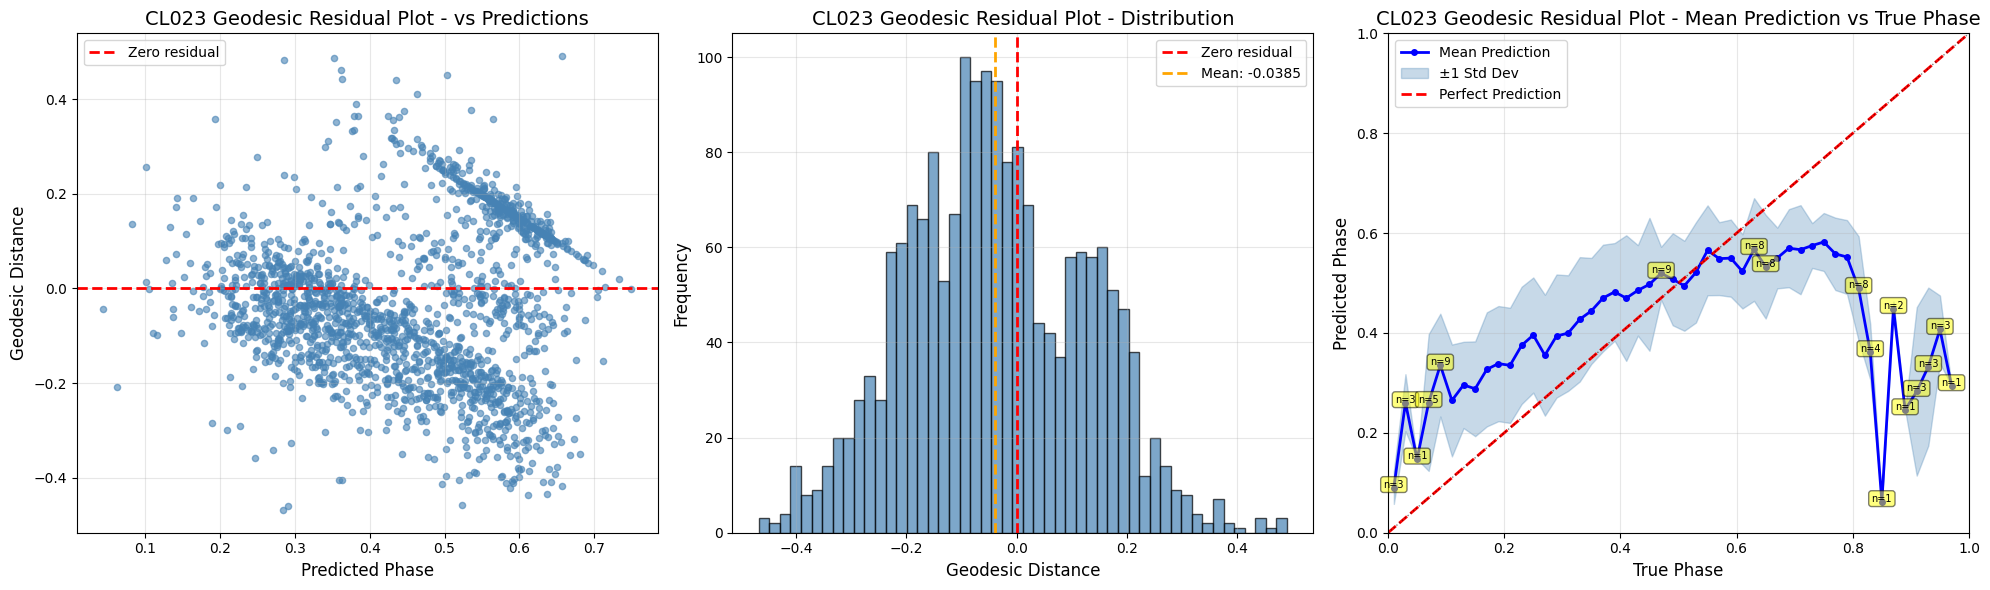

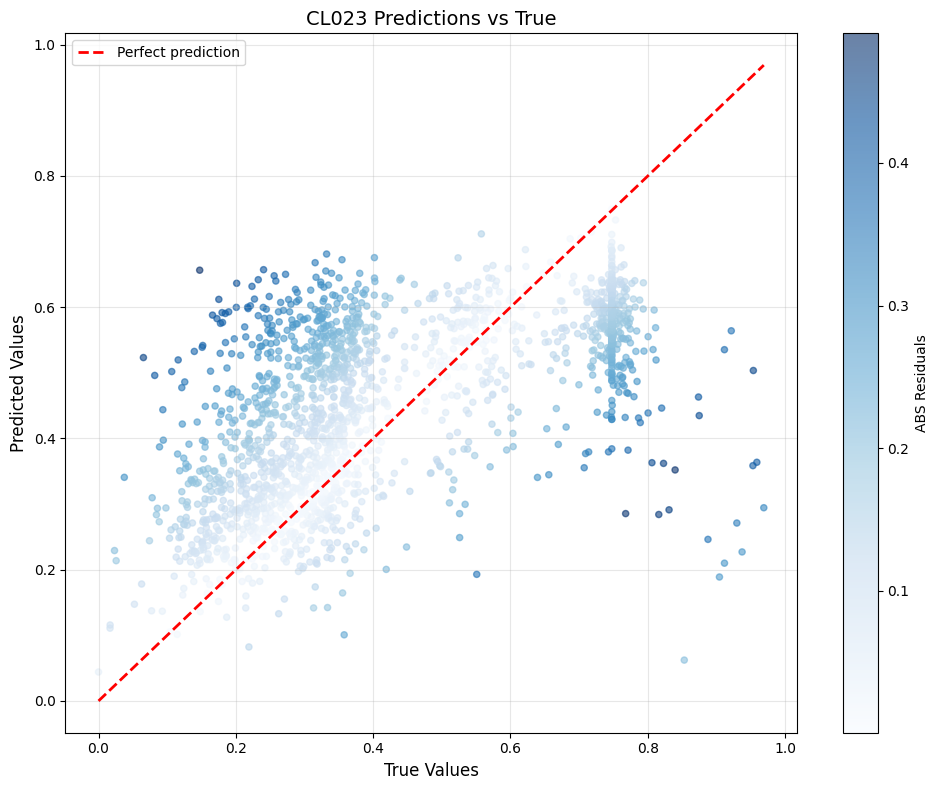

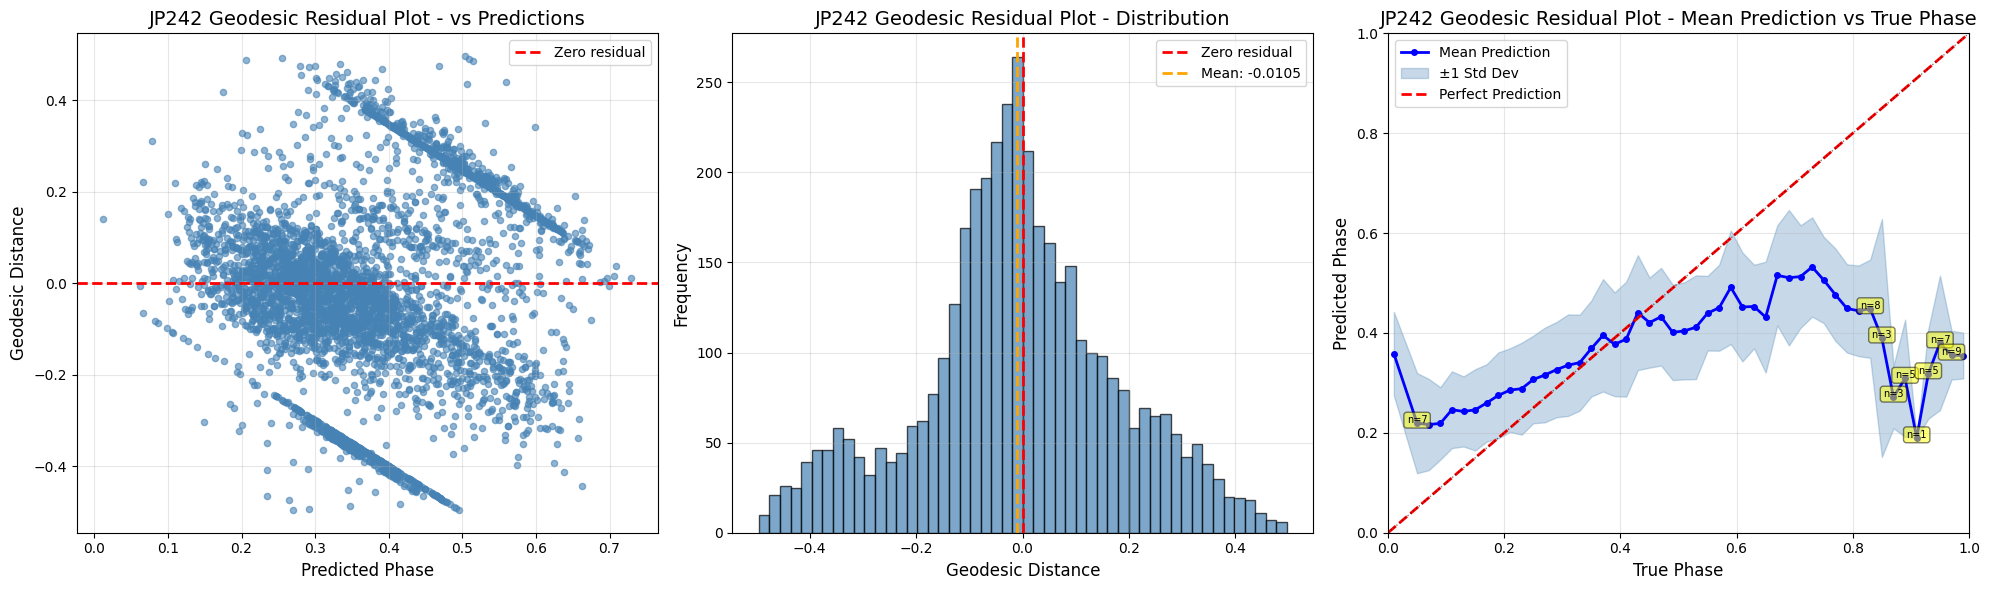

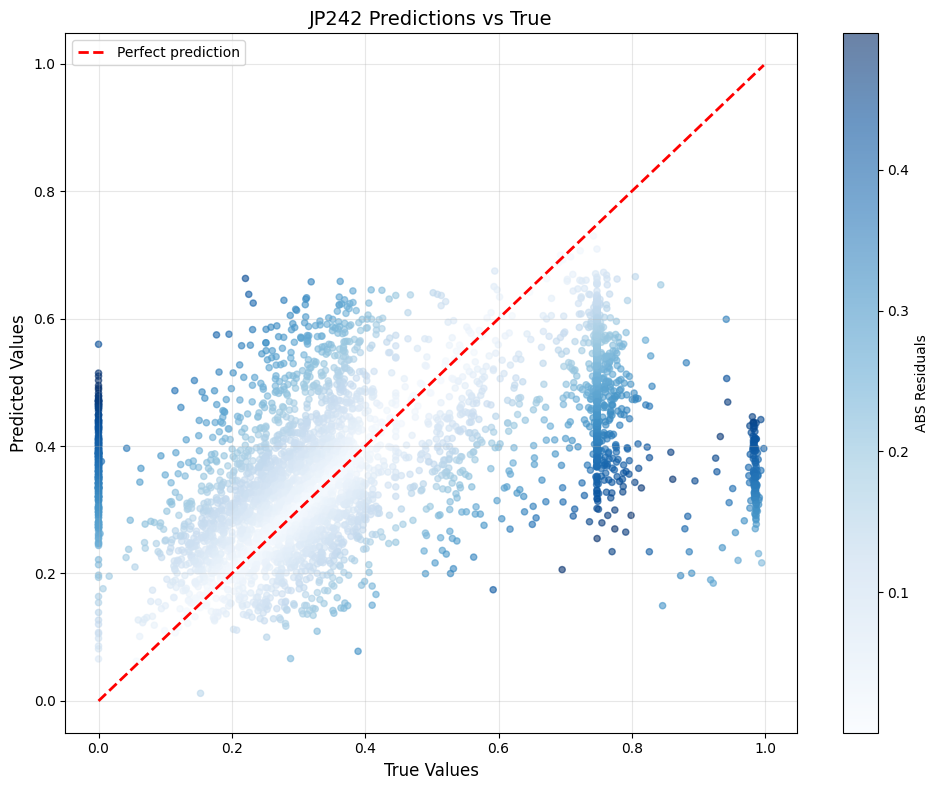

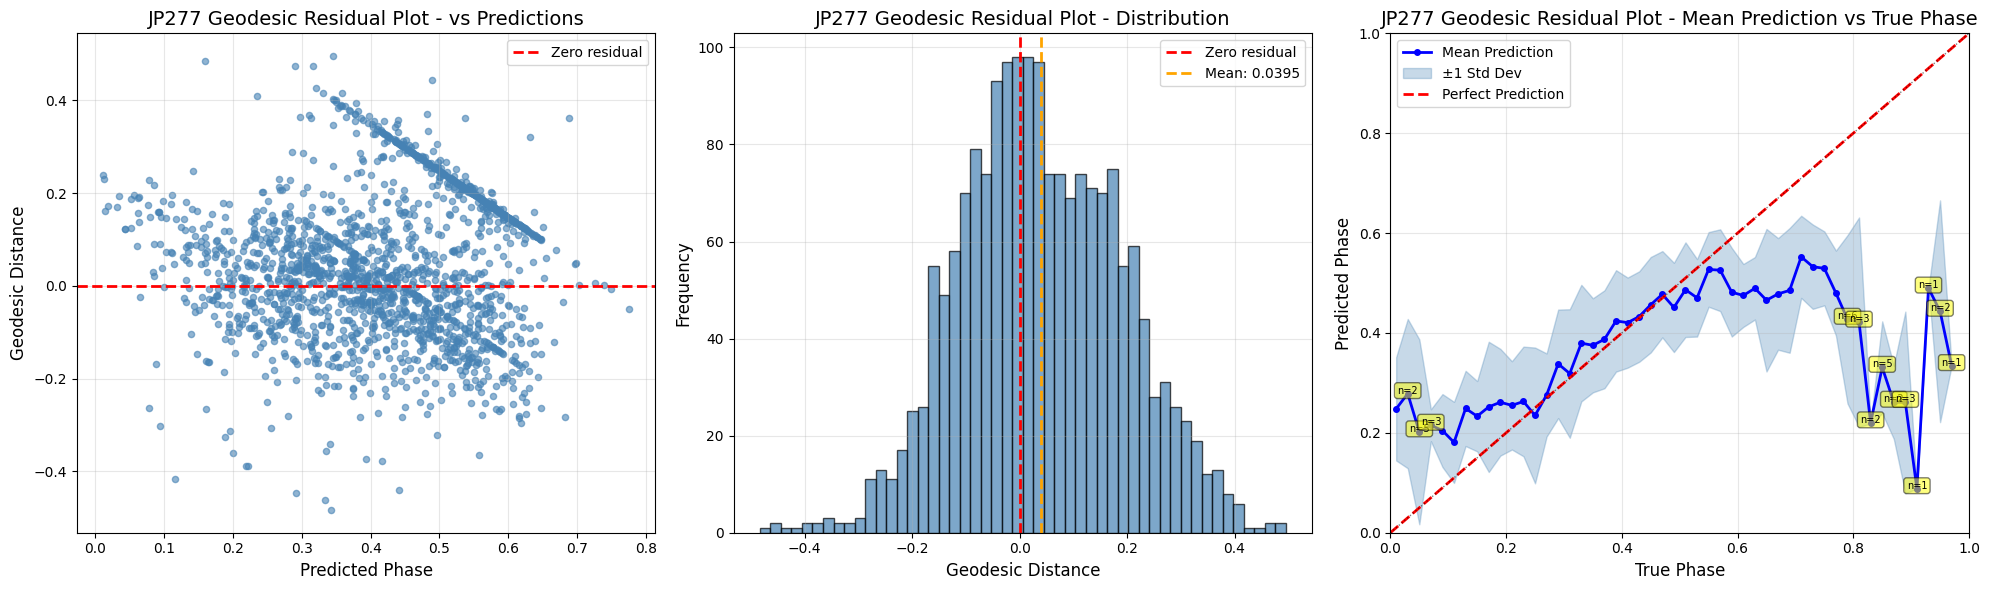

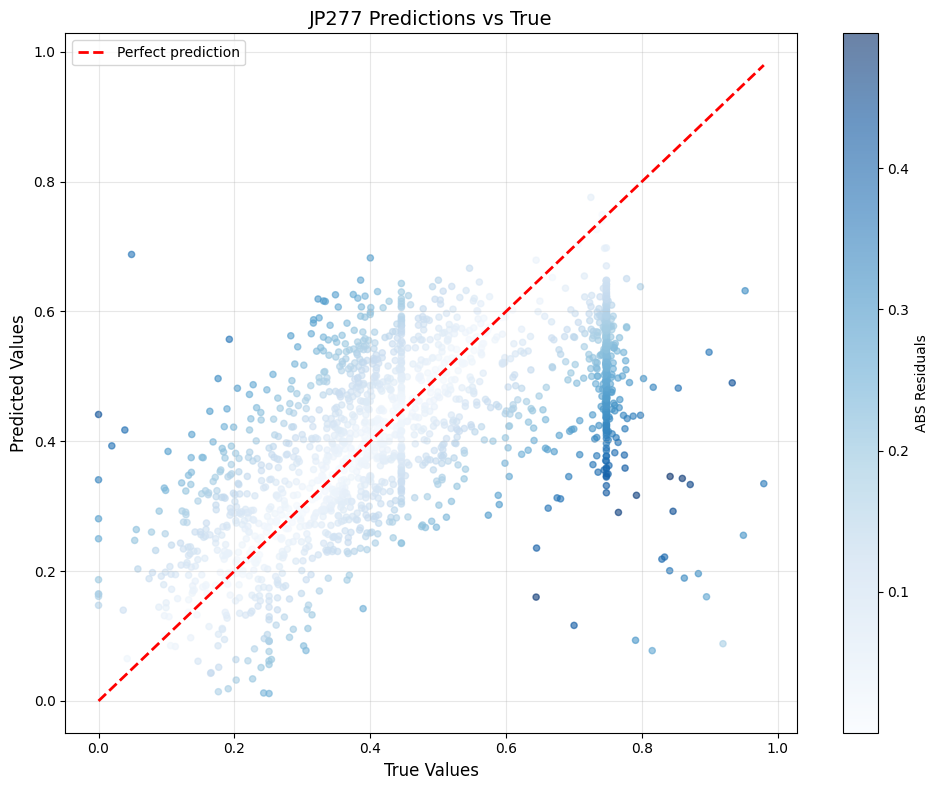

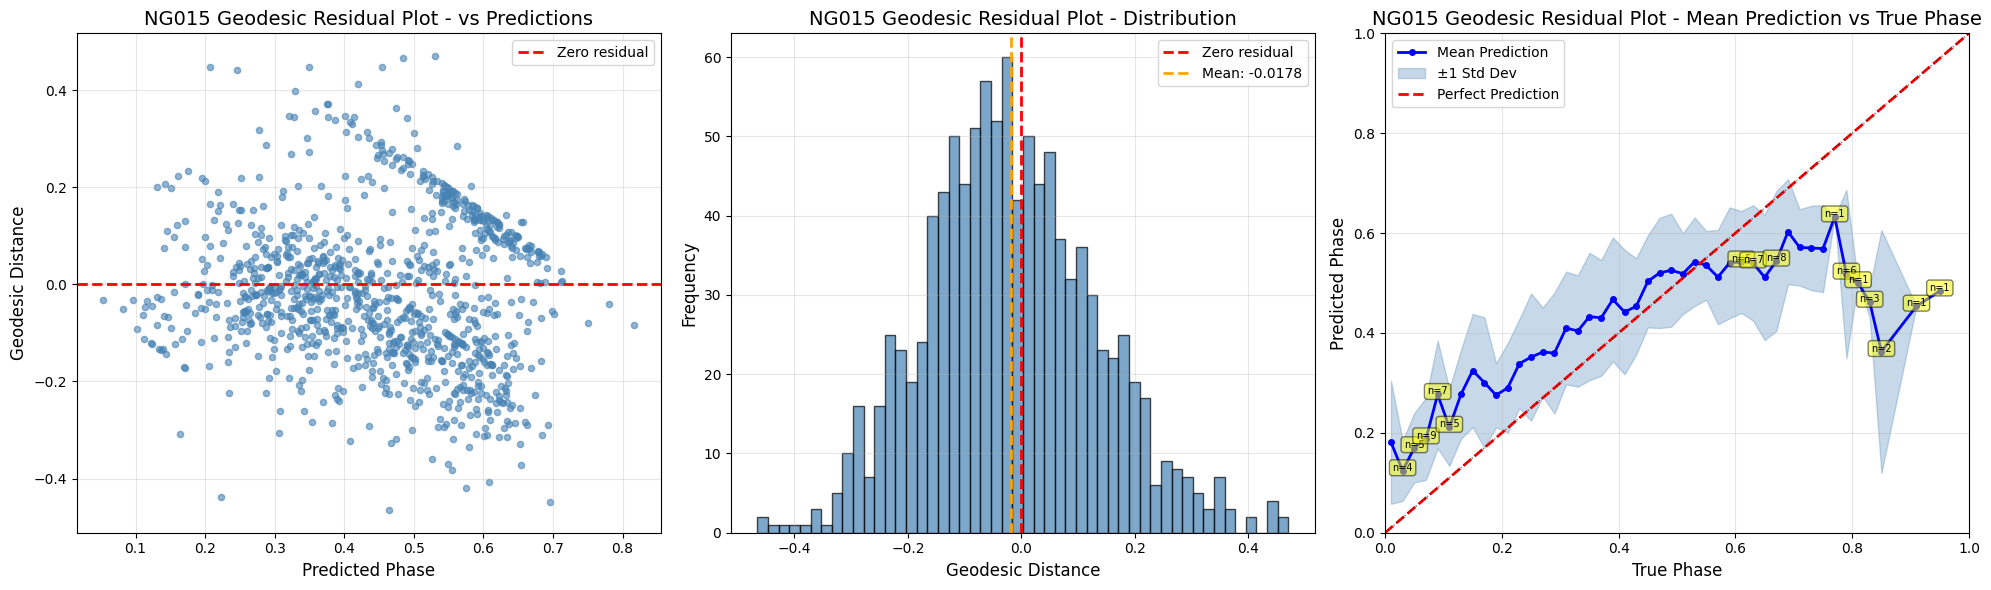

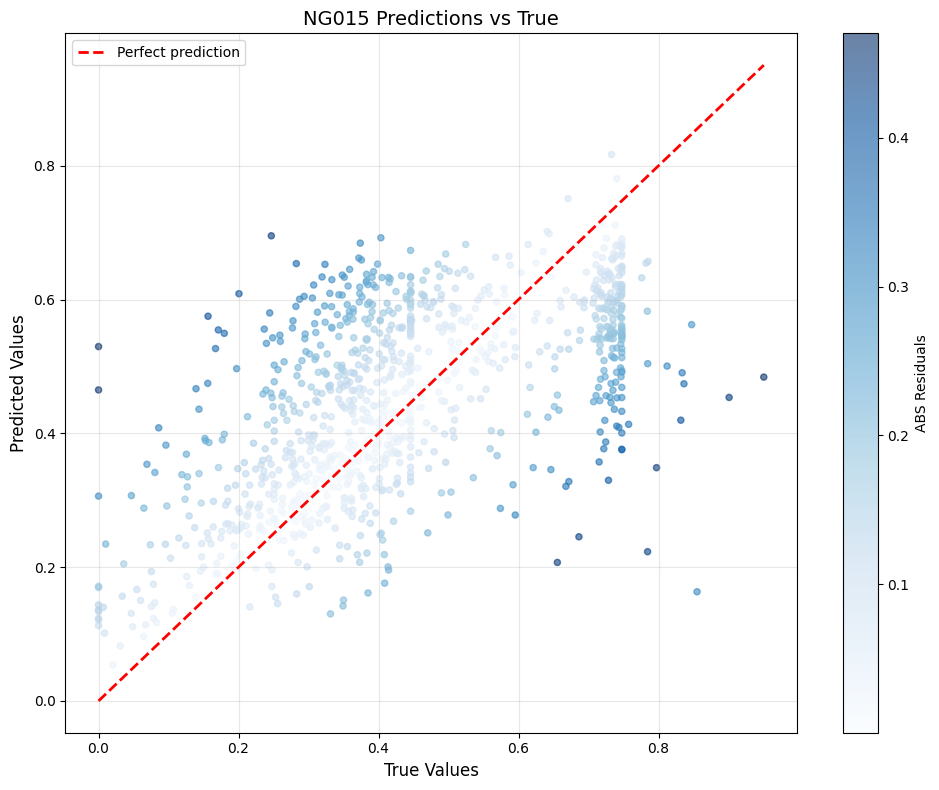

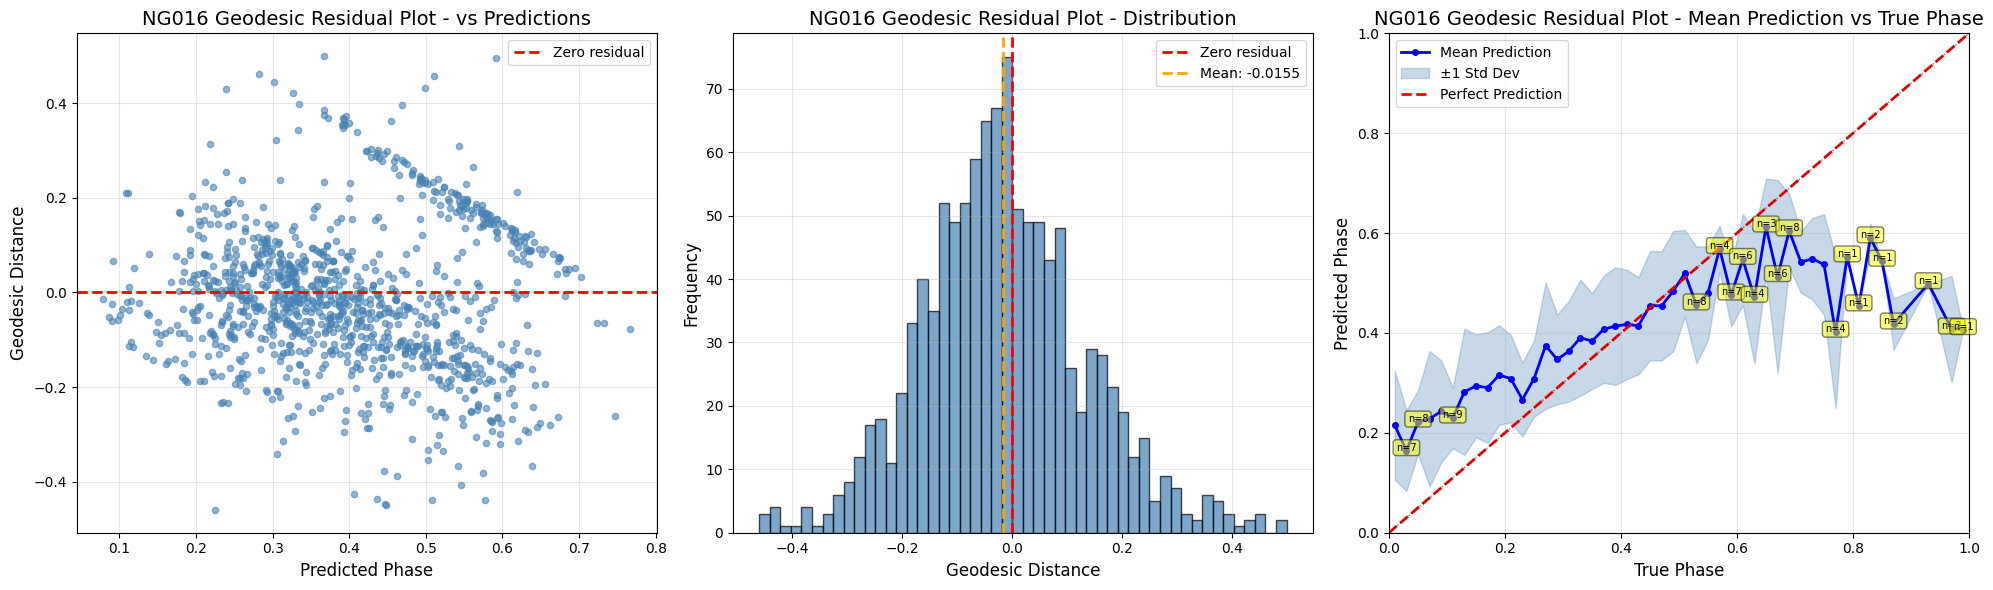

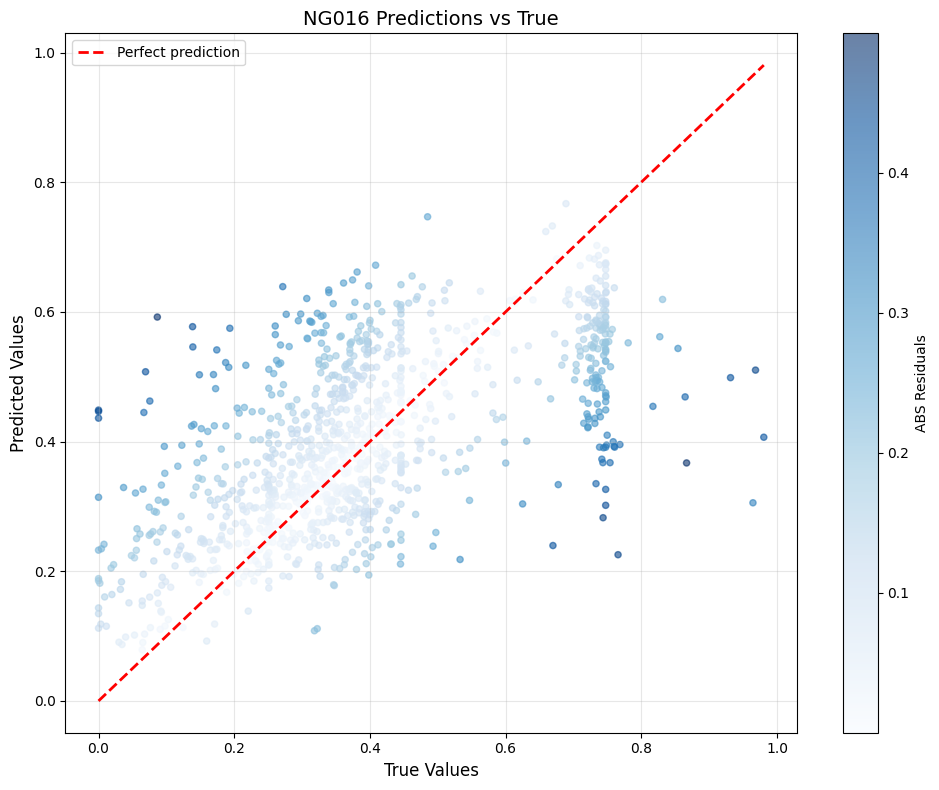

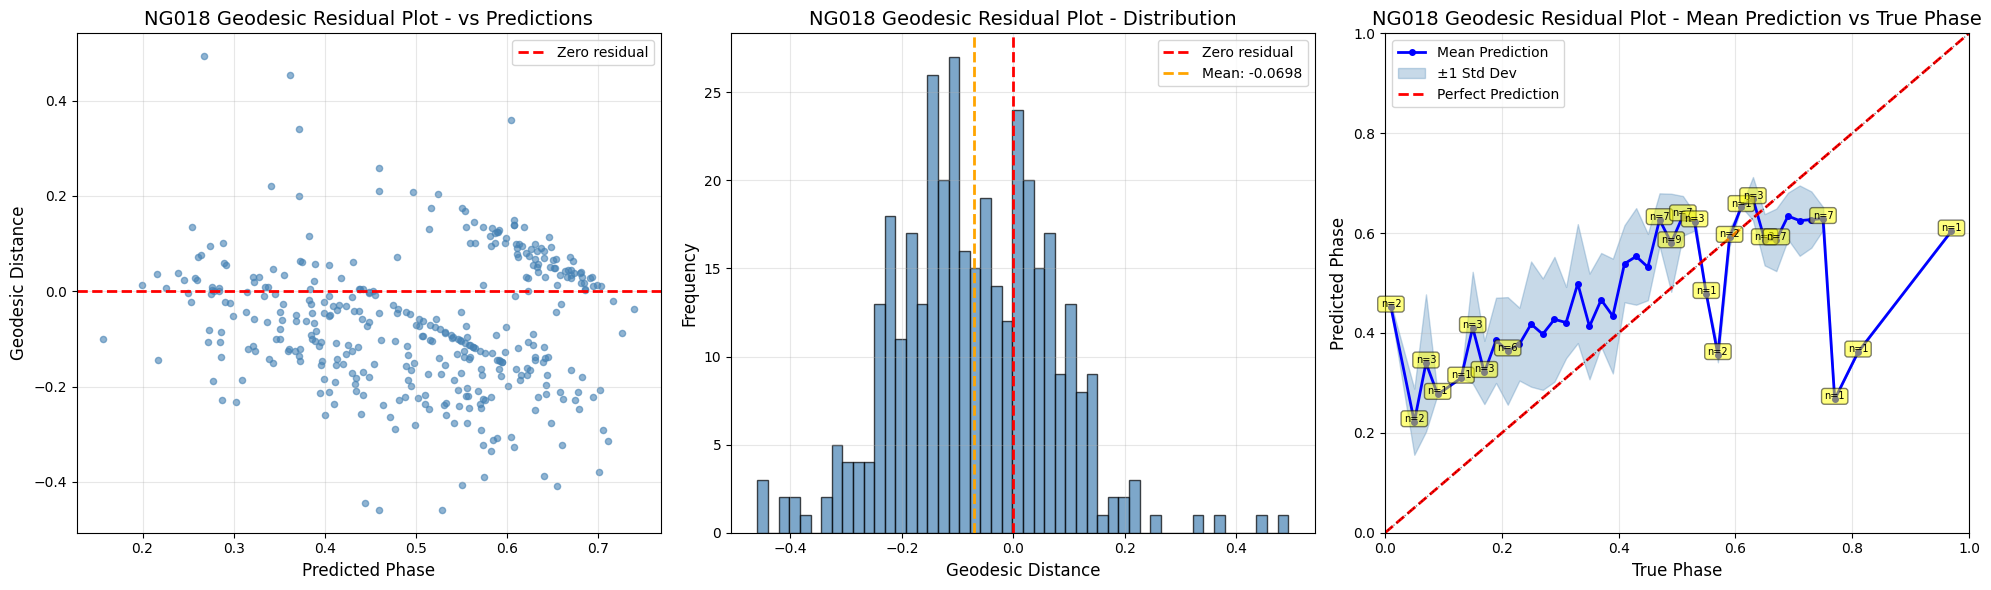

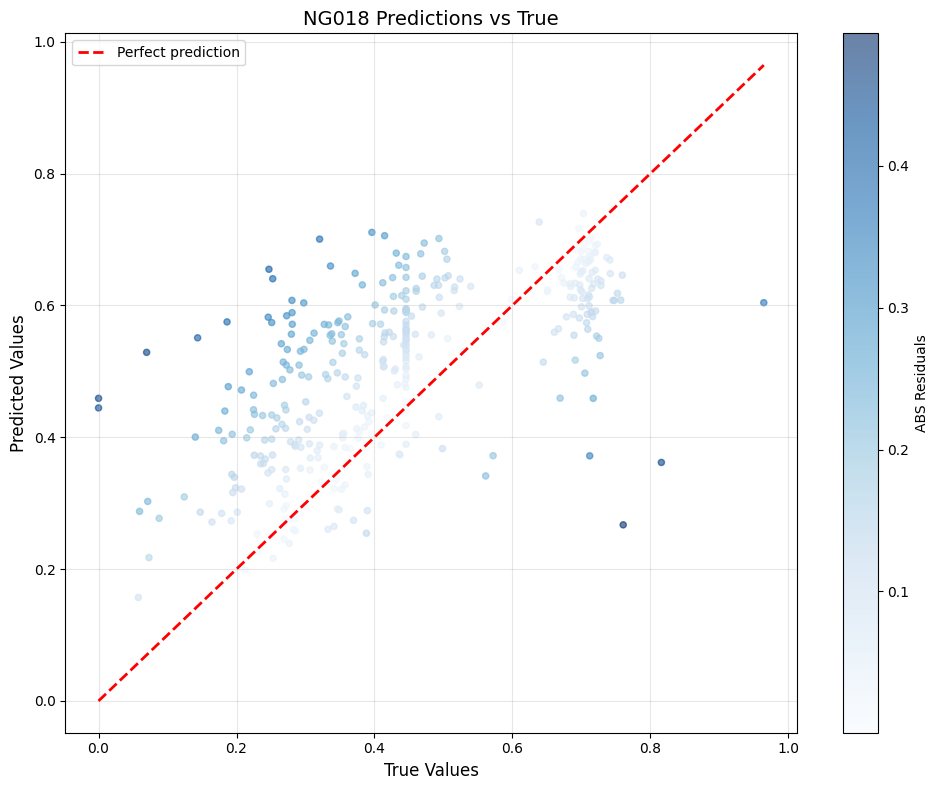

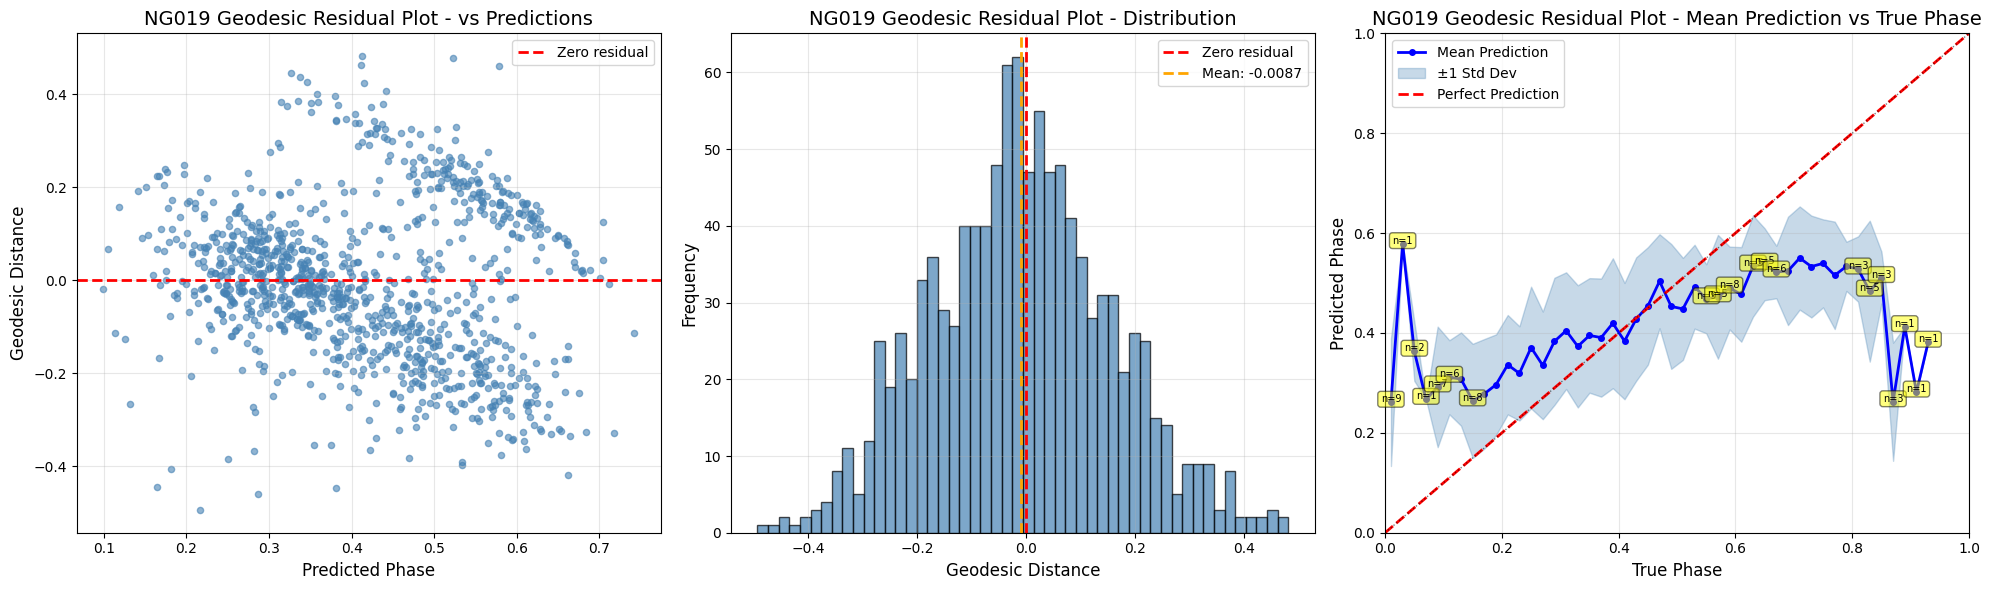

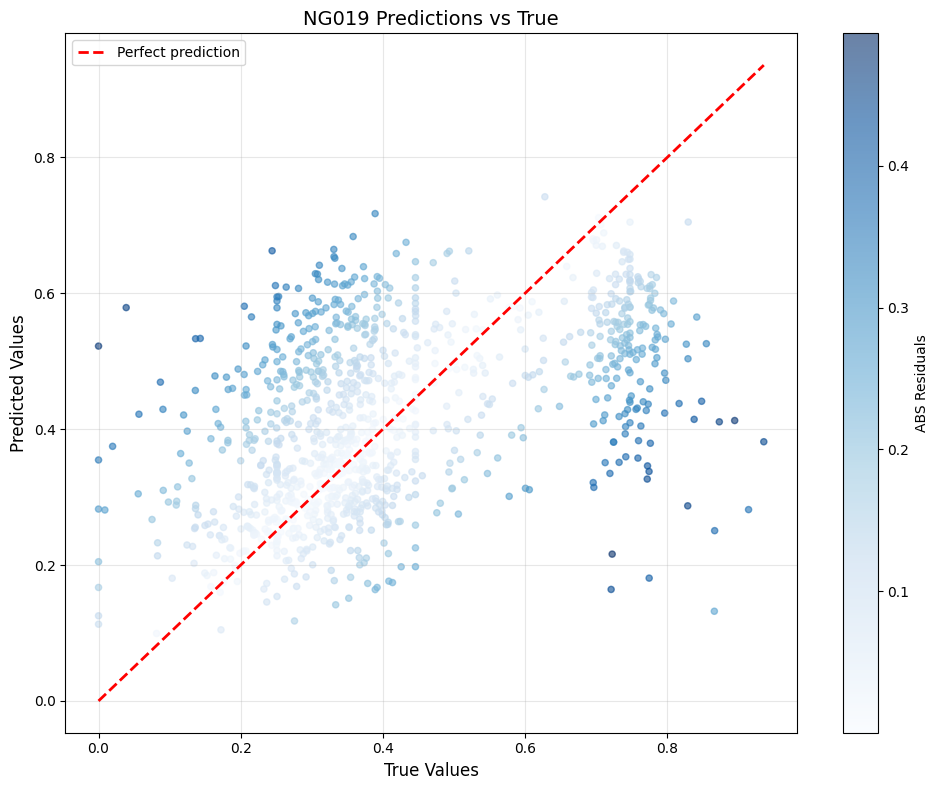

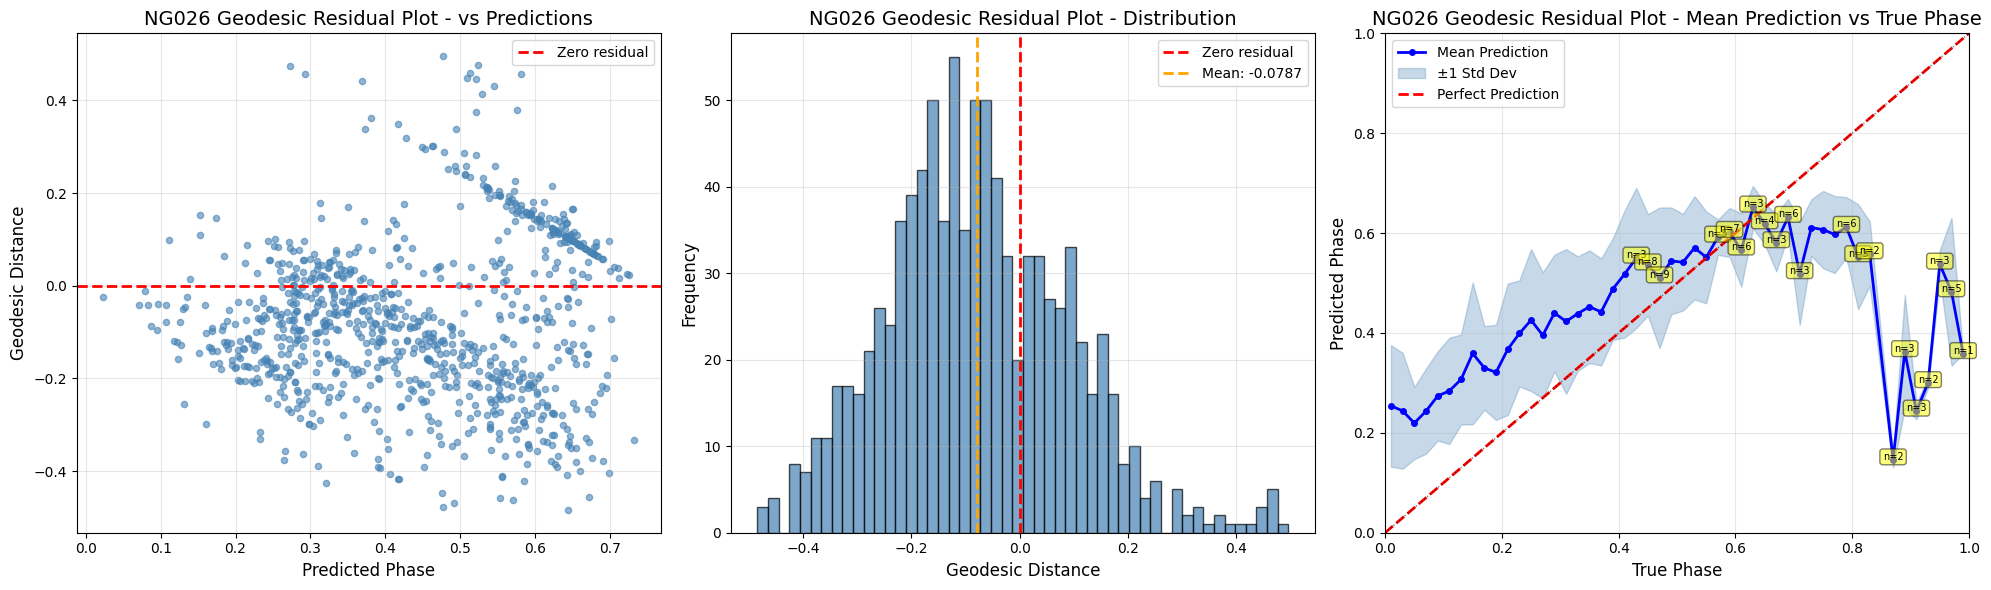

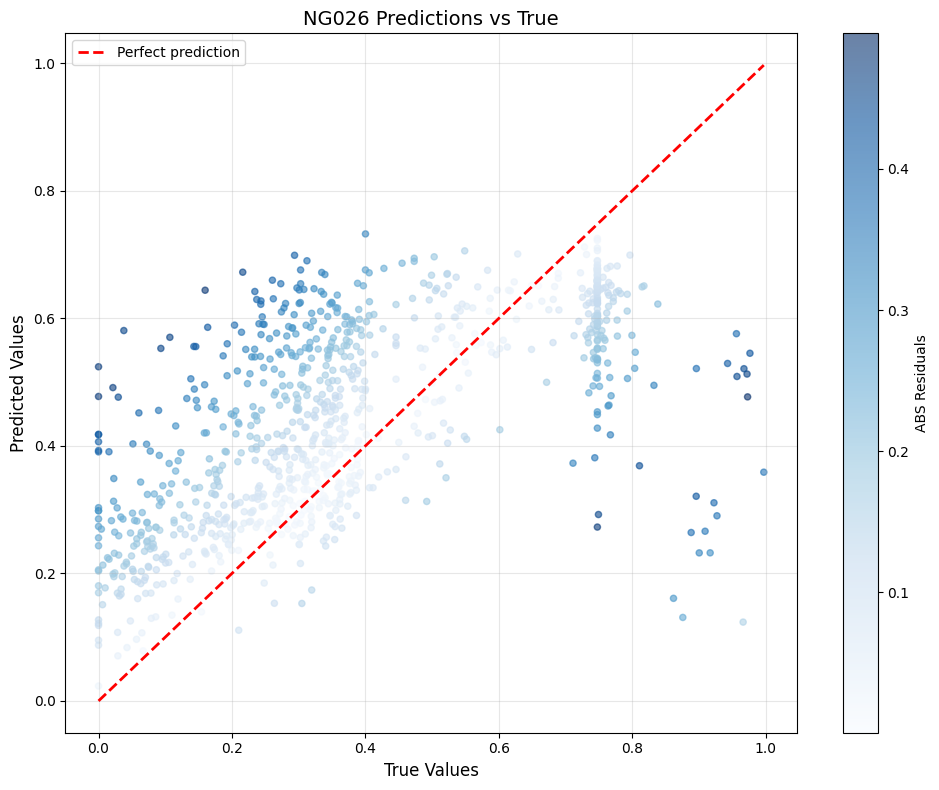

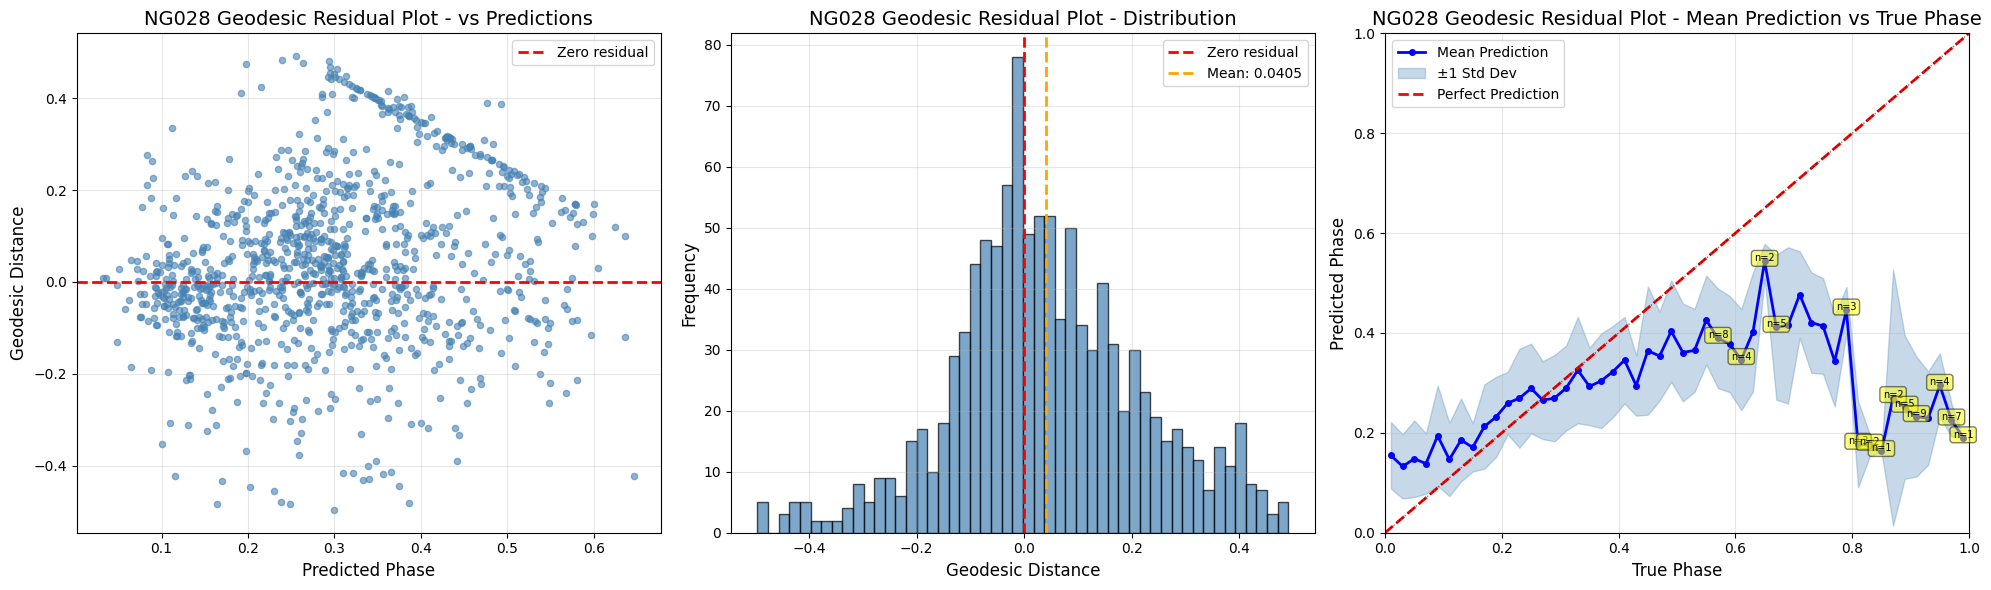

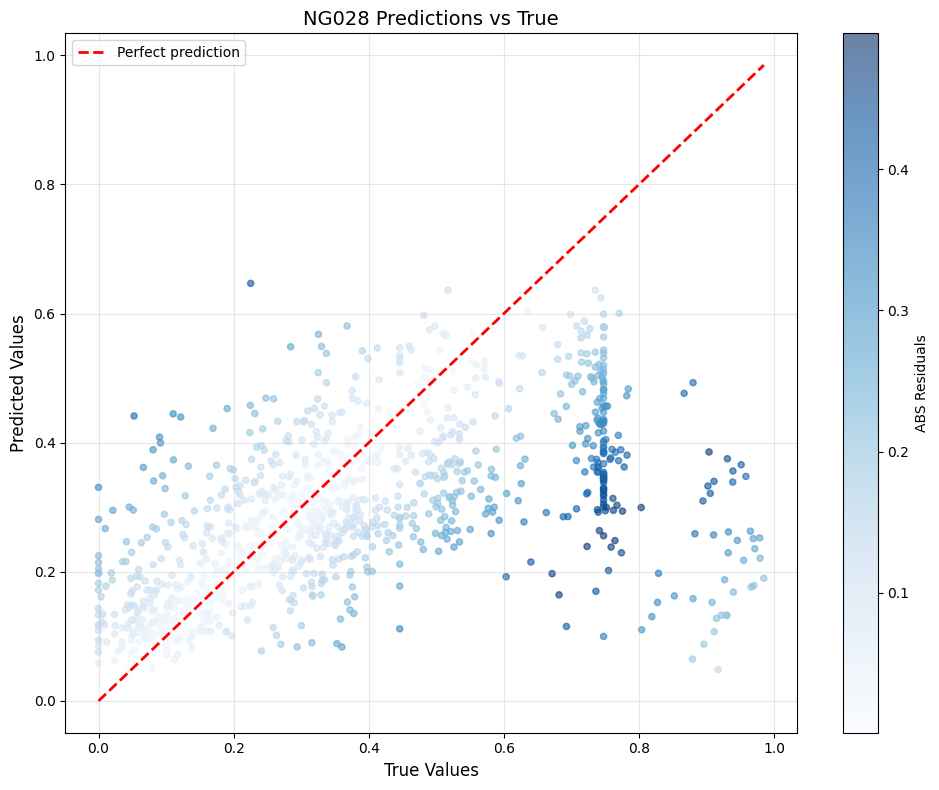

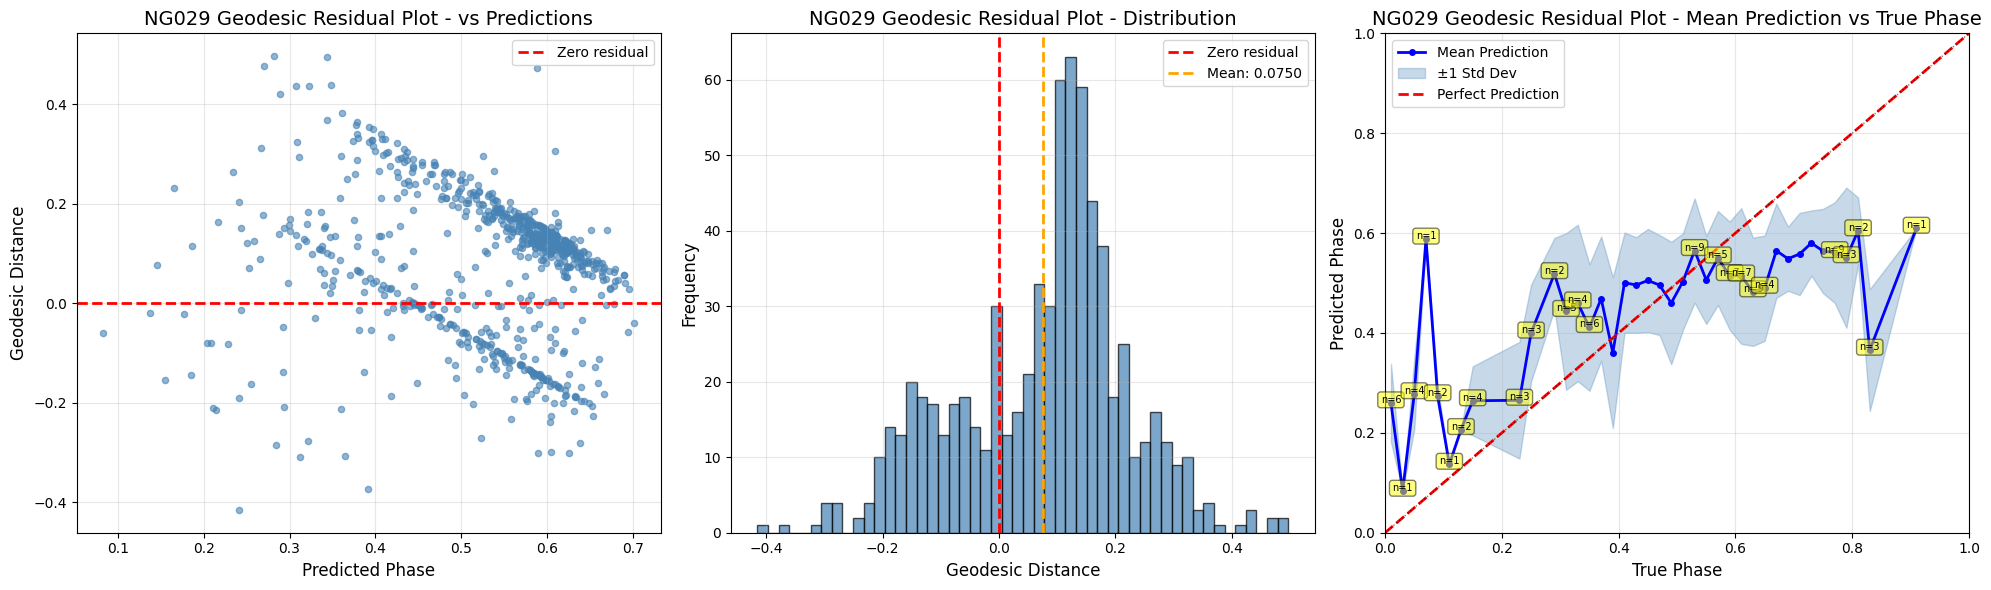

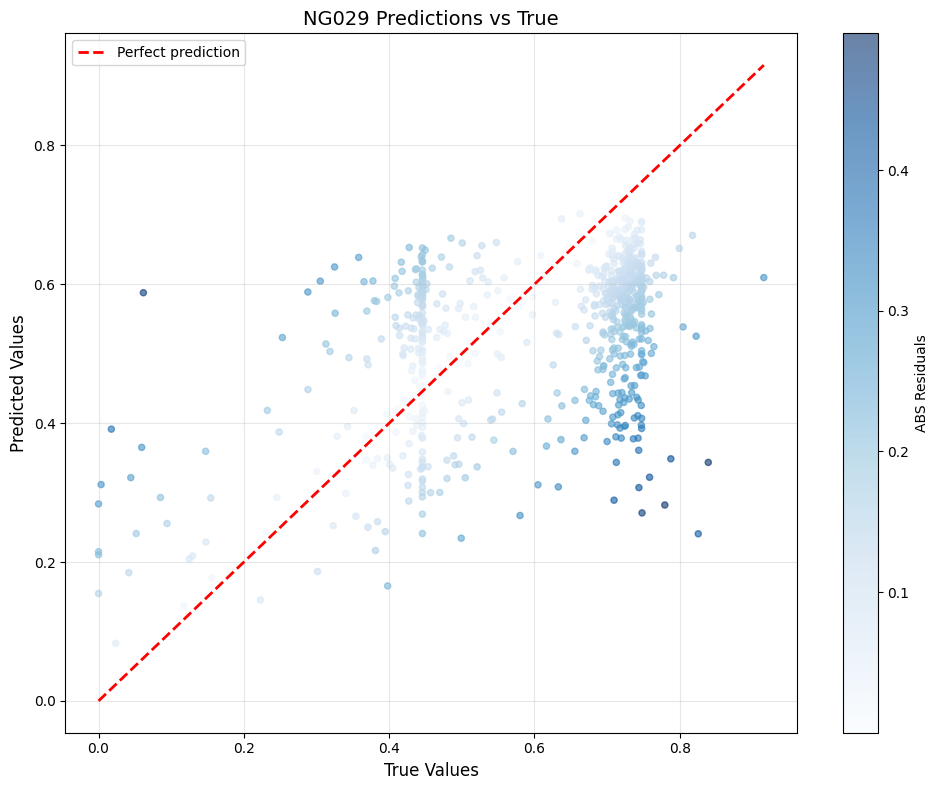

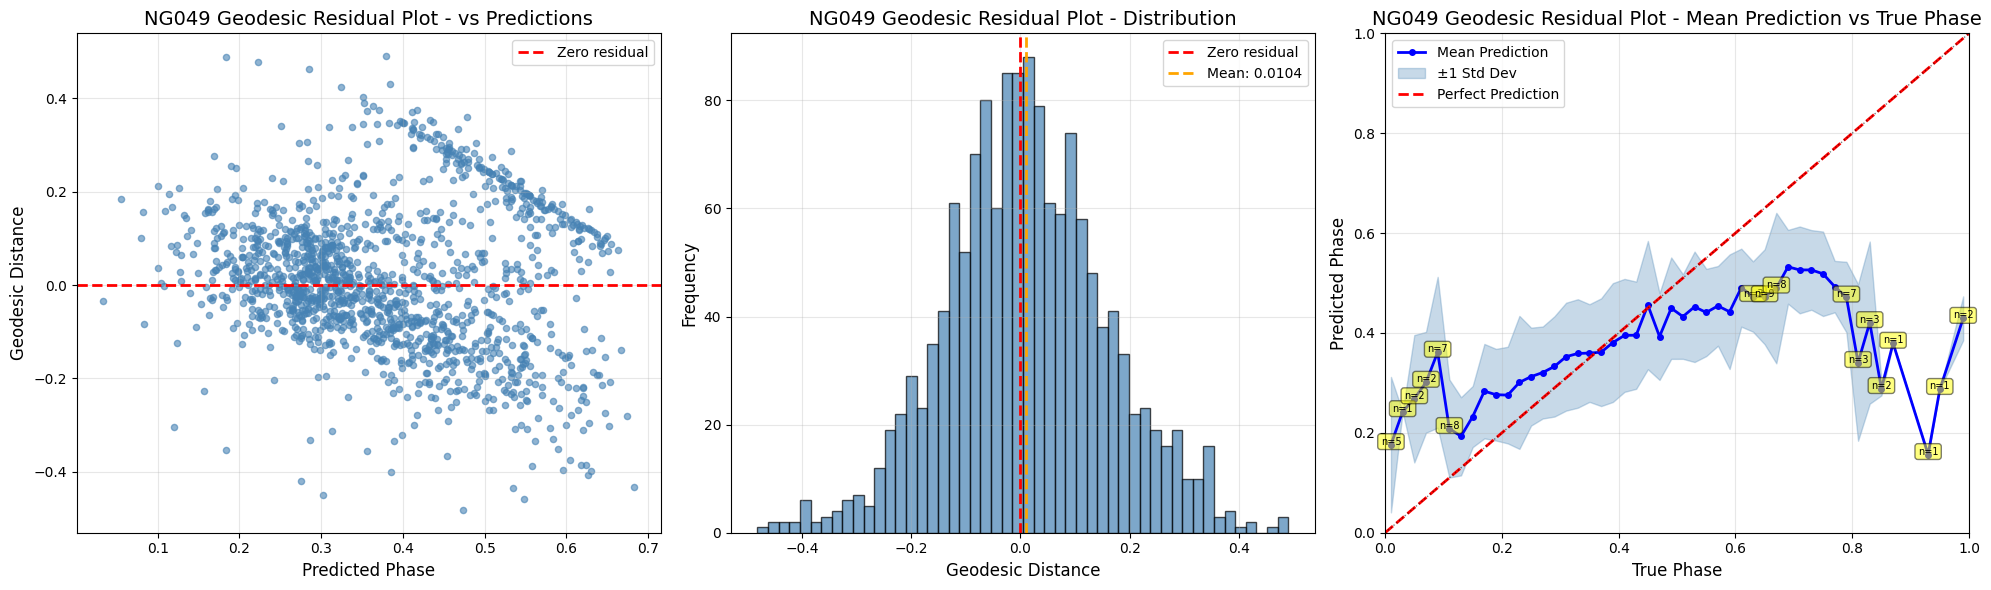

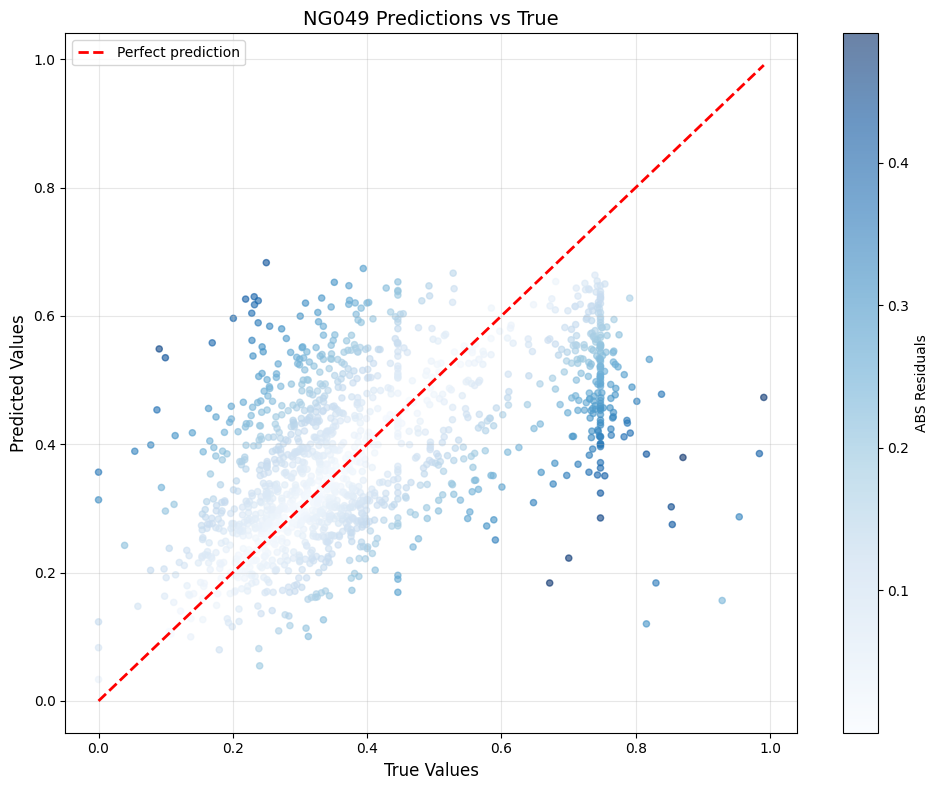

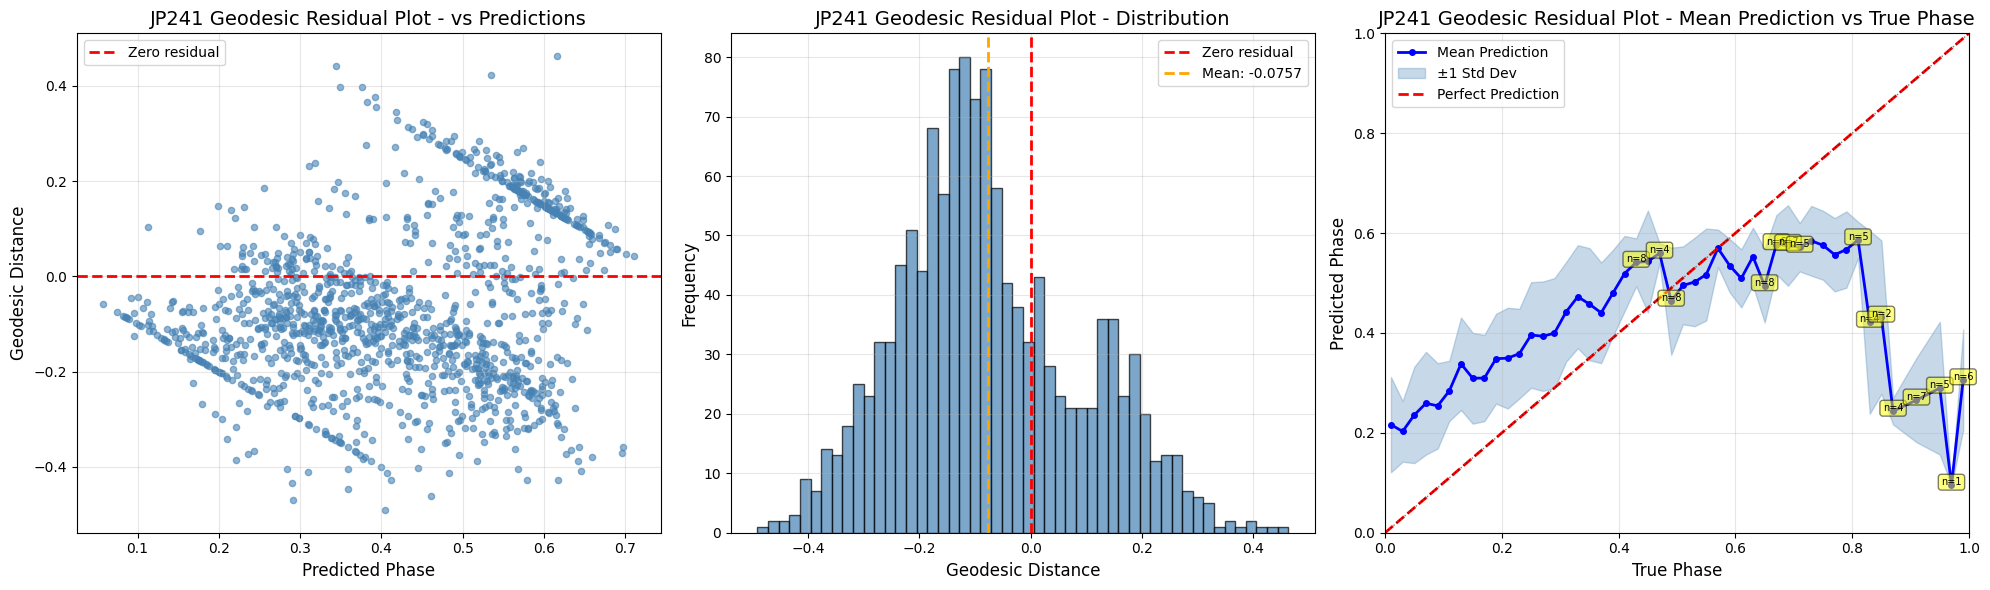

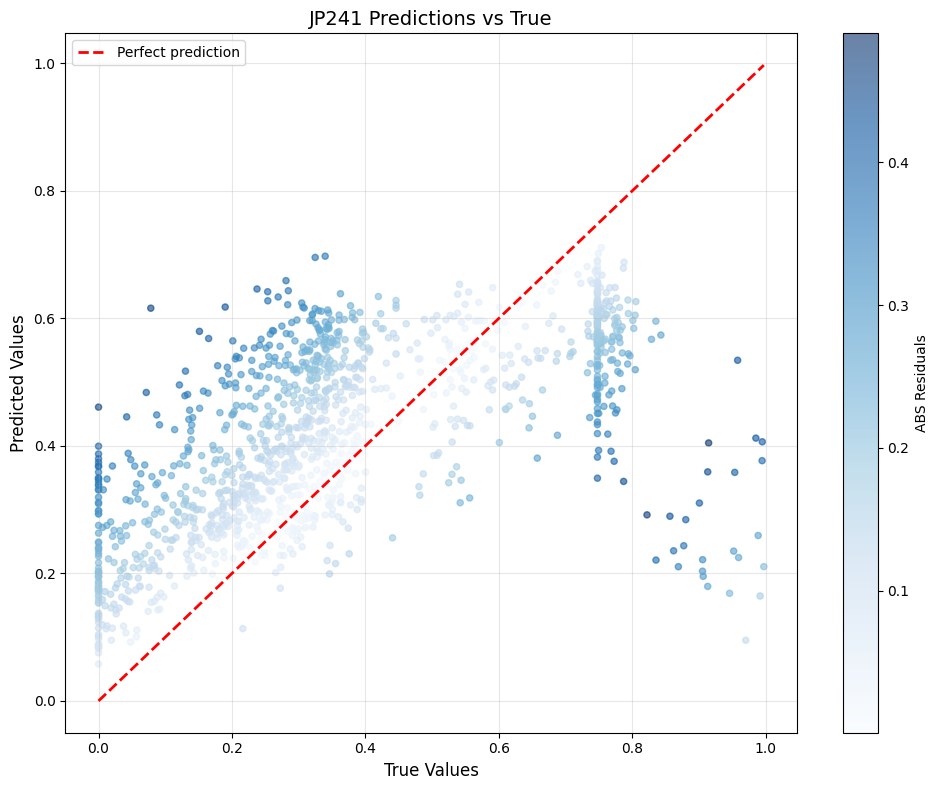

In [10]:
"""
Run leave-one-experiment-out cross-validation.
"""
import pandas as pd

print("=" * 80)
print("CROSS-VALIDATION: LEAVE-ONE-EXPERIMENT-OUT")
print("=" * 80)

cv_results = []
for split in tqdm(exp_id_cv_splits, desc="Cross-validation"):
    model, results = train_xgb_with_geodesic(**split, verbose=False)
    cv_results.append({
        'exp_id': split['exp_id'],
        'n_train': len(split['train_df']),
        'n_val': len(split['val_df']),
        'n_test': len(split['test_df']),
        'geodesic_mae': results.metrics.geodesic_mae,
        'geodesic_rmse': results.metrics.geodesic_rmse,
        'geodesic_r2': results.metrics.geodesic_r2,
        'geodesic_mse': results.metrics.geodesic_mse,
    })

cv_df = pd.DataFrame(cv_results)

print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS BY EXPERIMENT")
print("=" * 80)
print(cv_df.to_string(index=False))

In [11]:
"""
Compute weighted and unweighted averages across CV folds.
"""

# Compute weighted averages
total_test_samples = cv_df['n_test'].sum()
weights = cv_df['n_test'] / total_test_samples

weighted_mae = (cv_df['geodesic_mae'] * weights).sum()
weighted_rmse = (cv_df['geodesic_rmse'] * weights).sum()
weighted_r2 = (cv_df['geodesic_r2'] * weights).sum()
weighted_mse = (cv_df['geodesic_mse'] * weights).sum()

# Compute unweighted (simple) averages
simple_mae = cv_df['geodesic_mae'].mean()
simple_rmse = cv_df['geodesic_rmse'].mean()
simple_r2 = cv_df['geodesic_r2'].mean()
simple_mse = cv_df['geodesic_mse'].mean()

# Standard deviations
std_mae = cv_df['geodesic_mae'].std()
std_rmse = cv_df['geodesic_rmse'].std()
std_r2 = cv_df['geodesic_r2'].std()
std_mse = cv_df['geodesic_mse'].std()

# Weighted standard deviation
weighted_std_mae = np.sqrt((weights * (cv_df['geodesic_mae'] - weighted_mae)**2).sum())
weighted_std_rmse = np.sqrt((weights * (cv_df['geodesic_rmse'] - weighted_rmse)**2).sum())
weighted_std_r2 = np.sqrt((weights * (cv_df['geodesic_r2'] - weighted_r2)**2).sum())
weighted_std_mse = np.sqrt((weights * (cv_df['geodesic_mse'] - weighted_mse)**2).sum())

print("\n" + "=" * 80)
print("AGGREGATED METRICS")
print("=" * 80)
print(f"\n{'Metric':<20} {'Weighted Avg':<20} {'Simple Avg':<20} {'Weighted Std':<20}")
print("-" * 80)
print(f"{'Geodesic MAE':<20} {weighted_mae:.4f}              {simple_mae:.4f}              {weighted_std_mae:.4f}")
print(f"{'Geodesic RMSE':<20} {weighted_rmse:.4f}              {simple_rmse:.4f}              {weighted_std_rmse:.4f}")
print(f"{'Geodesic MSE':<20} {weighted_mse:.4f}              {simple_mse:.4f}              {weighted_std_mse:.4f}")
print(f"{'Geodesic R²':<20} {weighted_r2:.4f}              {simple_r2:.4f}              {weighted_std_r2:.4f}")

print(f"\nTotal samples across all folds: {total_test_samples}")
print(f"Number of folds: {len(cv_df)}")
print(f"Test set size range: {cv_df['n_test'].min()} - {cv_df['n_test'].max()}")


AGGREGATED METRICS

Metric               Weighted Avg         Simple Avg           Weighted Std        
--------------------------------------------------------------------------------
Geodesic MAE         0.1352              0.1337              0.0120
Geodesic RMSE        0.1704              0.1669              0.0150
Geodesic MSE         0.0293              0.0280              0.0051
Geodesic R²          0.3592              0.3366              0.0838

Total samples across all folds: 16759
Number of folds: 12
Test set size range: 376 - 4078


## 6. Feature Importance

In [13]:
"""
Analyze feature importance from XGBoost model.
"""

# Get feature importance
importance_gain = model_full_xgb.get_score(importance_type='gain')
importance_weight = model_full_xgb.get_score(importance_type='weight')

# Sort by gain
sorted_features = sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)

print("\n" + "=" * 80)
print("TOP 20 FEATURES BY XGBOOST GAIN")
print("=" * 80)

print(f"\n{'Rank':<5} {'Feature':<40} {'Gain':<15} {'Weight':<10}")
print("-" * 75)
for i, (name, gain) in enumerate(sorted_features[:20]):
    weight = importance_weight.get(name, 0)
    print(f"{i+1:<5} {name:<40} {gain:<15.2f} {weight:<10}")


TOP 20 FEATURES BY XGBOOST GAIN

Rank  Feature                                  Gain            Weight    
---------------------------------------------------------------------------
1     cell_area                                1.19            346.0     
2     cell_minor_axis_length                   0.97            181.0     
3     total_intensity_nucleus                  0.77            204.0     
4     nucleus_major_axis_length                0.53            218.0     
5     cell_perimeter                           0.53            157.0     
6     nucleus_perimeter                        0.37            191.0     
7     cell_major_axis_length                   0.33            135.0     
8     cell_nucleus_area_ratio                  0.27            167.0     
9     total_intensity_outside_nucleus          0.25            210.0     
10    cell_mean_intensity                      0.25            287.0     
11    nucleus_mean_intensity                   0.24            142.0     
12

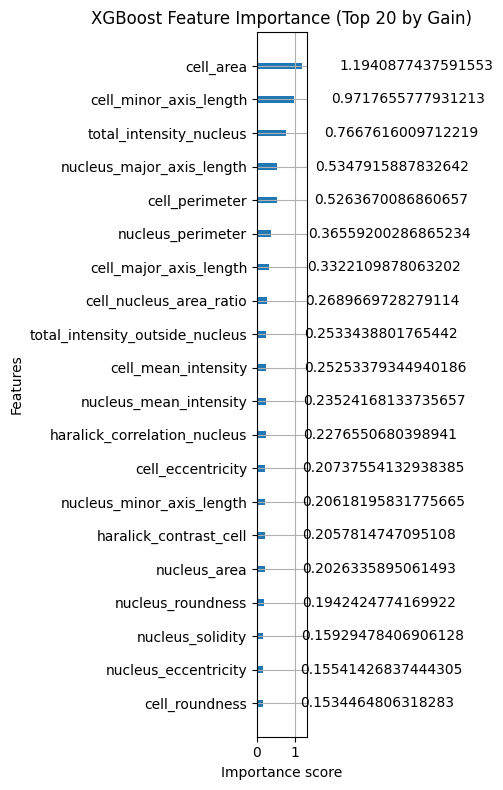

In [14]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model_full_xgb, ax=ax, importance_type='gain', max_num_features=20)
plt.title('XGBoost Feature Importance (Top 20 by Gain)')
plt.tight_layout()
plt.show()

### Shapely values


TOP 15 FEATURES (by average SHAP across all phases)
1   cell_area                                0.031364
2   cell_minor_axis_length                   0.027456
3   total_intensity_nucleus                  0.024484
4   nucleus_major_axis_length                0.019402
5   nucleus_perimeter                        0.014478
6   cell_perimeter                           0.014068
7   cell_eccentricity                        0.012155
8   nucleus_mean_intensity                   0.011383
9   total_intensity_outside_nucleus          0.011264
10  cell_mean_intensity                      0.010858
11  cell_major_axis_length                   0.008082
12  haralick_contrast_cell                   0.006689
13  cell_nucleus_area_ratio                  0.006553
14  cell_solidity                            0.006467
15  cell_roundness                           0.006053


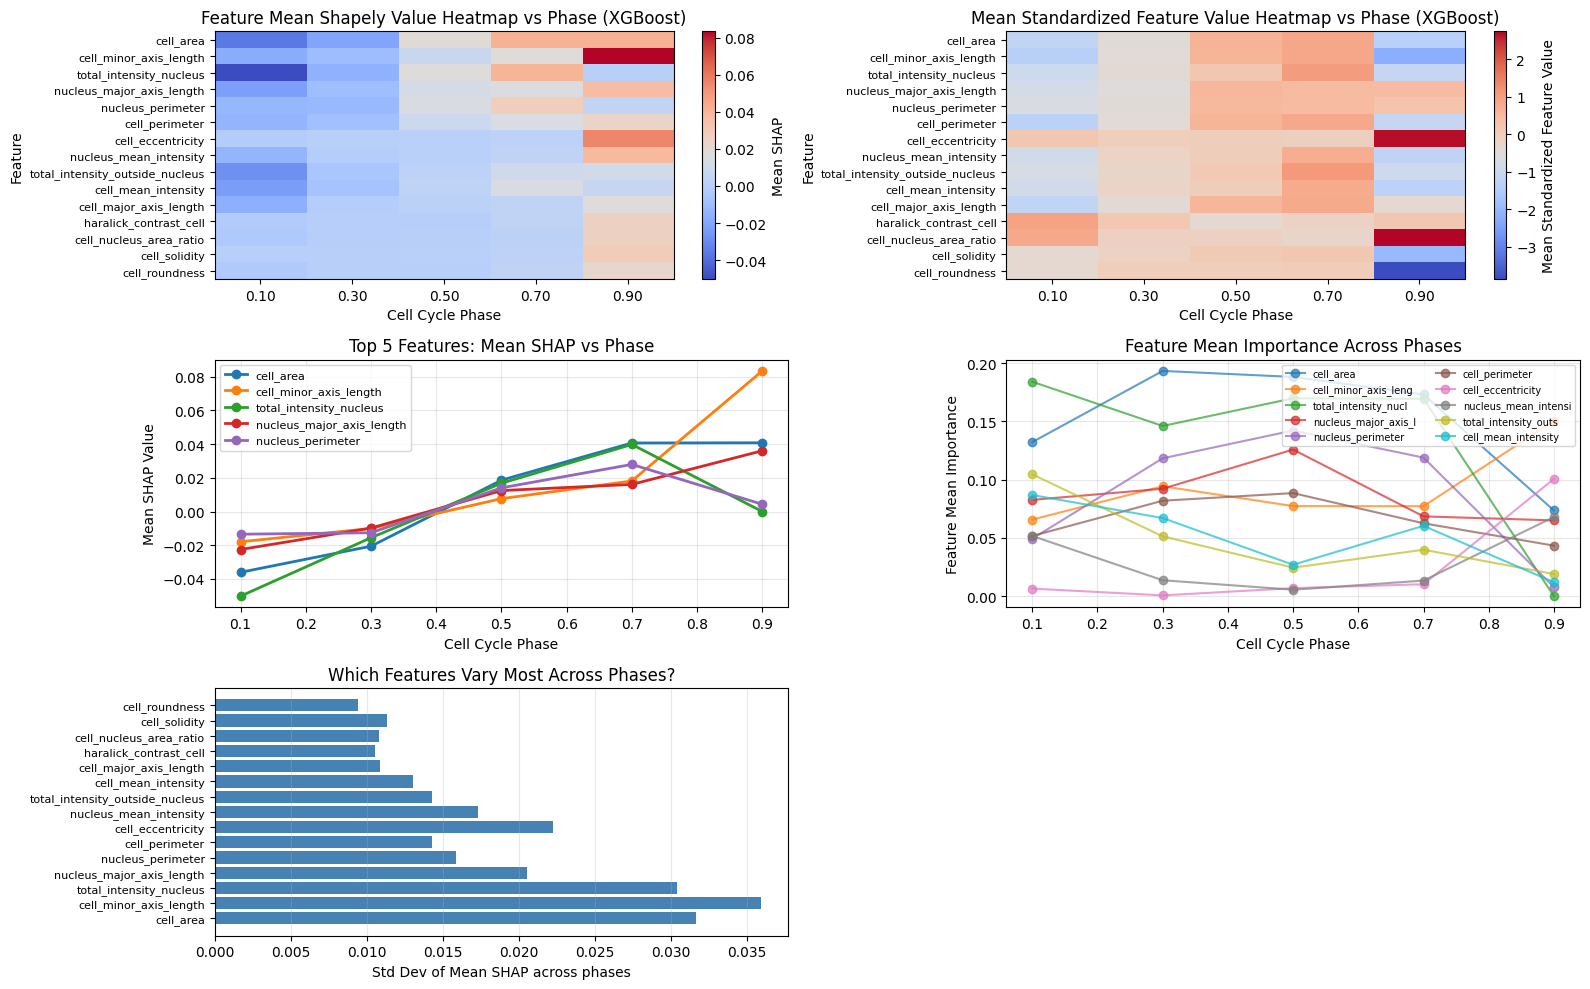


FEATURES WITH HIGHEST PHASE-DEPENDENT VARIABILITY

Rank  Feature                                  Mean SHAP    Std Dev      Coef. Var.  
-------------------------------------------------------------------------------------
1     cell_major_axis_length                   0.000720    0.010889    15.124315
2     nucleus_perimeter                        0.004048    0.015852    3.915960
3     cell_area                                0.008687    0.031682    3.646993
4     nucleus_mean_intensity                   0.005163    0.017307    3.352440
5     nucleus_major_axis_length                0.006450    0.020561    3.187865
6     cell_perimeter                           0.004936    0.014316    2.900505
7     cell_nucleus_area_ratio                  0.004692    0.010811    2.304185
8     cell_minor_axis_length                   0.016259    0.035945    2.210785
9     cell_roundness                           0.004420    0.009451    2.138284
10    haralick_contrast_cell                   0.004981

In [ ]:
"""
Analyze how SHAP feature importance changes across cell cycle phases for XGBoost.
"""

import shap
import matplotlib.pyplot as plt
import xgboost

print("=" * 80)
print("SHAP FEATURE IMPORTANCE vs CELL CYCLE PHASE (XGBoost)")
print("=" * 80)

# Define phase bins
n_phase_bins = 5
phase_bins = np.linspace(0, 1, n_phase_bins + 1)
phase_labels = [f"{phase_bins[i]:.2f}-{phase_bins[i+1]:.2f}" for i in range(n_phase_bins)]

# Prepare SHAP explainer for XGBoost
# Use KernelExplainer for tree models
print("Creating SHAP KernelExplainer...")

# Sample background data
n_background = min(500, len(train_df))
X_background = train_df[all_feature_cols].values[:n_background]

dmatrix = xgb.DMatrix(val_df[all_feature_cols])
phase_pred = model_full_xgb.predict(dmatrix) % 1.0

# Create wrapper function
def model_predict(X):
    dmatrix = xgb.DMatrix(X, feature_names=all_feature_cols)
    return model_full_xgb.predict(dmatrix) % 1.0

explainer = shap.KernelExplainer(model_predict, X_background)

# Compute SHAP values for each phase bin
shap_by_phase = []
phase_bin_centers = []
abs_shap_by_phase = []
mean_feature_values = []

for i in tqdm(range(n_phase_bins), desc="Computing SHAP by phase"):
    # Get samples in this phase bin
    phase_mask = (phase_pred >= phase_bins[i]) & \
                 (phase_pred < phase_bins[i+1])
    
    # Sample up to 200 samples from this bin
    n_samples_bin = min(200, phase_mask.sum())
    bin_indices = np.where(phase_mask.ravel())[0]
    np.random.shuffle(bin_indices)
    bin_indices = bin_indices[:n_samples_bin]
    
    X_bin = val_df[all_feature_cols].values[bin_indices]
    mean_feature_values.append(X_bin.mean(axis=0))
    print(f"  Computing SHAP for phase {phase_labels[i]} ({len(X_bin)} samples)...")
    
    # TreeExplainer is much faster than KernelExplainer
    shap_values_bin = explainer.shap_values(X_bin)
    
    # Store mean absolute SHAP values
    mean_abs_shap_bin = np.abs(shap_values_bin.mean(axis=0))
    mean_shap_bin = shap_values_bin.mean(axis=0)
    abs_shap_by_phase.append(mean_abs_shap_bin)
    shap_by_phase.append(mean_shap_bin)
    phase_bin_centers.append((phase_bins[i] + phase_bins[i+1]) / 2)

# Convert to array for easier plotting
shap_by_phase = np.array(shap_by_phase)  # Shape: (n_bins, n_features)

# Find top features across all phases
overall_importance = np.array(abs_shap_by_phase).mean(axis=0)
top_feature_indices = np.argsort(overall_importance)[-15:][::-1]
top_feature_names = [all_feature_cols[int(i)] for i in top_feature_indices]

print("\n" + "=" * 80)
print("TOP 15 FEATURES (by average SHAP across all phases)")
print("=" * 80)
for i, (idx, name) in enumerate(zip(top_feature_indices, top_feature_names)):
    print(f"{i+1:<3} {name:<40} {overall_importance[idx]:.6f}")

# Visualize how feature importance changes with phase
fig = plt.figure(figsize=(16, 10))

# 1. Heatmap of top features vs phase
ax1 = plt.subplot(3, 2, 1)
im = ax1.imshow(shap_by_phase[:, top_feature_indices].T, 
                aspect='auto', cmap='coolwarm')
ax1.set_xlabel('Cell Cycle Phase')
ax1.set_ylabel('Feature')
ax1.set_xticks(range(len(phase_bin_centers)))
ax1.set_xticklabels([f"{c:.2f}" for c in phase_bin_centers])
ax1.set_yticks(range(len(top_feature_names)))
ax1.set_yticklabels(top_feature_names, fontsize=8)
ax1.set_title('Feature Mean Shapely Value Heatmap vs Phase (XGBoost)')
plt.colorbar(im, ax=ax1, label='Mean SHAP')


ax1 = plt.subplot(3, 2, 2)
im = ax1.imshow(np.array(mean_feature_values)[:, top_feature_indices].T, 
                aspect='auto', cmap='coolwarm')
ax1.set_xlabel('Cell Cycle Phase')
ax1.set_ylabel('Feature')
ax1.set_xticks(range(len(phase_bin_centers)))
ax1.set_xticklabels([f"{c:.2f}" for c in phase_bin_centers])
ax1.set_yticks(range(len(top_feature_names)))
ax1.set_yticklabels(top_feature_names, fontsize=8)
ax1.set_title('Mean Standardized Feature Value Heatmap vs Phase (XGBoost)')
plt.colorbar(im, ax=ax1, label='Mean Standardized Feature Value')

# 2. Line plot for selected features
ax2 = plt.subplot(3, 2, 3)
n_features_to_plot = min(5, len(top_feature_indices))
for i in range(n_features_to_plot):
    idx = top_feature_indices[i]
    ax2.plot(phase_bin_centers, shap_by_phase[:, idx], 
             marker='o', label=top_feature_names[i], linewidth=2)
ax2.set_xlabel('Cell Cycle Phase')
ax2.set_ylabel('Mean SHAP Value')
ax2.set_title(f'Top {n_features_to_plot} Features: Mean SHAP vs Phase')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Feature ranking changes
ax3 = plt.subplot(3, 2, 4)
for i in range(min(10, len(top_feature_indices))):
    idx = top_feature_indices[i]
    # Rank within each phase bin
    ranks = []
    for phase_shap in shap_by_phase:
        relative_importance = phase_shap[idx] / np.sum(phase_shap)
        ranks.append(relative_importance)
    ax3.plot(phase_bin_centers, ranks, marker='o', 
             label=all_feature_cols[idx][:20], alpha=0.7)

ax3.set_xlabel('Cell Cycle Phase')
ax3.set_ylabel('Feature Mean Importance')
ax3.set_title('Feature Mean Importance Across Phases')
ax3.legend(fontsize=7, loc='best', ncol=2)
ax3.grid(True, alpha=0.3)


# 4. Variance in importance across phases
ax4 = plt.subplot(3, 2, 5)
importance_variance = shap_by_phase[:, top_feature_indices].std(axis=0)
importance_mean = shap_by_phase[:, top_feature_indices].mean(axis=0)

ax4.barh(range(len(top_feature_names)), importance_variance, color='steelblue')
ax4.set_yticks(range(len(top_feature_names)))
ax4.set_yticklabels(top_feature_names, fontsize=8)
ax4.set_xlabel('Std Dev of Mean SHAP across phases')
ax4.set_title('Which Features Vary Most Across Phases?')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Identify features with highest phase-dependent changes
print("\n" + "=" * 80)
print("FEATURES WITH HIGHEST PHASE-DEPENDENT VARIABILITY")
print("=" * 80)

relative_variance = importance_variance / (importance_mean + 1e-8)
sorted_var_indices = np.argsort(relative_variance)[::-1]

print(f"\n{'Rank':<5} {'Feature':<40} {'Mean SHAP':<12} {'Std Dev':<12} {'Coef. Var.':<12}")
print("-" * 85)
for i in range(min(15, len(sorted_var_indices))):
    idx = sorted_var_indices[i]
    feat_idx = top_feature_indices[idx]
    print(f"{i+1:<5} {all_feature_cols[feat_idx]:<40} "
          f"{importance_mean[idx]:.6f}    {importance_variance[idx]:.6f}    "
          f"{relative_variance[idx]:.6f}")

print("\nInterpretation:")
print("- High std dev → Feature importance changes significantly across cell cycle")
print("- Low std dev → Feature consistently important (or unimportant)")
print("- Check line plot to see if importance peaks at specific phases")